In [1]:
import numpy as np
import matplotlib.pyplot as plt 
from pathlib import Path

In [2]:
log_dir = Path("/Users/s3002149/Library/CloudStorage/OneDrive-UniversityofEdinburgh/Daten SU(2) Pure Gauge/raw_data/logs")
logs = list(log_dir.glob("*.log"))

for log in logs:
    print(log.name)

L8x8x8x8_beta2_md10_trajL1.25_traj1000_ckpt5.log
L8x8x8x8_beta2_md5_trajL1.0_traj100_ckpt5.log
L8x8x8x8_beta4_md10_trajL1.0_traj100_ckpt5.log
L8x8x8x8_beta2_md10_trajL1.0_traj1000_ckpt5.log
L8x8x8x8_beta2_md10_trajL2_traj100_ckpt5.log
L8x8x8x8_beta2_md10_trajL1.0_traj100_ckpt5.log
L8x8x8x8_beta2_md10_trajL0.5_traj100_ckpt5.log
L8x8x8x8_beta2_md5_trajL1.0_traj1000_ckpt5.log
L8x8x8x8_beta2_md10_trajL0.5_traj1000_ckpt5.log
L8x8x8x8_beta2_md40_trajL1.0_traj100_ckpt5.log
L8x8x8x8_beta6_md10_trajL1.0_traj1000_ckpt5.log
L8x8x8x8_beta2_md20_trajL1.0_traj1000_ckpt5.log
L8x8x8x8_beta2_md8_trajL1.0_traj100_ckpt5.log
L8x8x8x8_beta6_md10_trajL1.0_traj100_ckpt5.log
L8x8x8x8_beta4_md10_trajL1.0_traj1000_ckpt5.log
L12x12x12x12_beta5.6_md20_trajL1.0_traj2_ckpt5.log
L8x8x8x8_beta2_md10_trajL2_traj1000_ckpt5.log
L8x8x8x8_beta8_md10_trajL1.0_traj1000_ckpt5.log
L8x8x8x8_beta2_md20_trajL1.0_traj100_ckpt5.log
L8x8x8x8_beta2_md8_trajL1.0_traj1000_ckpt5.log
L8x8x8x8_beta8_md10_trajL1.0_traj100_ckpt5.log
L8x8x8

In [3]:
import re
from pathlib import Path

def parse_log_name(path):

    name = path.name

    result = {}

    m = re.search(r"L(\d+x\d+x\d+x\d+)", name)
    if m:
        result["lattice"] = m.group(1)

    m = re.search(r"_beta([\d.]+)", name)
    if m:
        result["beta"] = float(m.group(1))

    m = re.search(r"_md(\d+)", name)
    if m:
        result["mdsteps"] = int(m.group(1))

    m = re.search(r"_trajL([\d.]+)", name)
    if m:
        result["trajL"] = float(m.group(1))

    m = re.search(r"_traj(\d+)", name)
    if m:
        result["trajectories"] = int(m.group(1))

    m = re.search(r"_ckpt(\d+)", name)
    if m:
        result["checkpoint"] = int(m.group(1))

    return result

In [4]:
for log in logs:
    print(parse_log_name(log))

{'lattice': '8x8x8x8', 'beta': 2.0, 'mdsteps': 10, 'trajL': 1.25, 'trajectories': 1000, 'checkpoint': 5}
{'lattice': '8x8x8x8', 'beta': 2.0, 'mdsteps': 5, 'trajL': 1.0, 'trajectories': 100, 'checkpoint': 5}
{'lattice': '8x8x8x8', 'beta': 4.0, 'mdsteps': 10, 'trajL': 1.0, 'trajectories': 100, 'checkpoint': 5}
{'lattice': '8x8x8x8', 'beta': 2.0, 'mdsteps': 10, 'trajL': 1.0, 'trajectories': 1000, 'checkpoint': 5}
{'lattice': '8x8x8x8', 'beta': 2.0, 'mdsteps': 10, 'trajL': 2.0, 'trajectories': 100, 'checkpoint': 5}
{'lattice': '8x8x8x8', 'beta': 2.0, 'mdsteps': 10, 'trajL': 1.0, 'trajectories': 100, 'checkpoint': 5}
{'lattice': '8x8x8x8', 'beta': 2.0, 'mdsteps': 10, 'trajL': 0.5, 'trajectories': 100, 'checkpoint': 5}
{'lattice': '8x8x8x8', 'beta': 2.0, 'mdsteps': 5, 'trajL': 1.0, 'trajectories': 1000, 'checkpoint': 5}
{'lattice': '8x8x8x8', 'beta': 2.0, 'mdsteps': 10, 'trajL': 0.5, 'trajectories': 1000, 'checkpoint': 5}
{'lattice': '8x8x8x8', 'beta': 2.0, 'mdsteps': 40, 'trajL': 1.0, 'traj

In [5]:
import pandas as pd

data = []

for log in logs:
    row = parse_log_name(log)
    row["file"] = log
    data.append(row)

df = pd.DataFrame(data)

df

,lattice,beta,mdsteps,trajL,trajectories,checkpoint,file
0,8x8x8x8,2.0,10,1.25,1000,5,/Users/s3002149/Library/CloudStorage/OneDrive-...
1,8x8x8x8,2.0,5,1.00,100,5,/Users/s3002149/Library/CloudStorage/OneDrive-...
2,8x8x8x8,4.0,10,1.00,100,5,/Users/s3002149/Library/CloudStorage/OneDrive-...
3,8x8x8x8,2.0,10,1.00,1000,5,/Users/s3002149/Library/CloudStorage/OneDrive-...
4,8x8x8x8,2.0,10,2.00,100,5,/Users/s3002149/Library/CloudStorage/OneDrive-...
5,8x8x8x8,2.0,10,1.00,100,5,/Users/s3002149/Library/CloudStorage/OneDrive-...
6,8x8x8x8,2.0,10,0.50,100,5,/Users/s3002149/Library/CloudStorage/OneDrive-...
7,8x8x8x8,2.0,5,1.00,1000,5,/Users/s3002149/Library/CloudStorage/OneDrive-...
8,8x8x8x8,2.0,10,0.50,1000,5,/Users/s3002149/Library/CloudStorage/OneDrive-...
9,8x8x8x8,2.0,40,1.00,100,5,/Users/s3002149/Library/CloudStorage/OneDrive-...


In [6]:
def parse_plaquette(logfile):

    data = []

    with open(logfile) as f:
        for line in f:

            m = re.search(
                r"Plaquette:\s+\[\s*(\d+)\s*\]\s+([\d\.Ee+-]+)",
                line
            )

            if m:
                data.append(
                    {
                        "trajectory": int(m.group(1)),
                        "plaquette": float(m.group(2))
                    }
                )

    df = pd.DataFrame(data)

    # doppelte MPI-Ausgaben entfernen
    df = df.drop_duplicates(
        subset=["trajectory", "plaquette"]
    )

    return df.to_dict("records")

In [7]:
measurements = []

for log in logs:

    # Parameter aus Dateinamen
    params = parse_log_name(log)

    # Plaquette Werte aus Log
    plaqs = parse_plaquette(log)

    for p in plaqs:
        p.update(params)
        p["file"] = log.name
        measurements.append(p)


df = pd.DataFrame(measurements)

df.head()

,trajectory,plaquette,lattice,beta,mdsteps,trajL,trajectories,checkpoint,file
0,1,0.282783,8x8x8x8,2.0,10,1.25,1000,5,L8x8x8x8_beta2_md10_trajL1.25_traj1000_ckpt5.log
1,2,0.379957,8x8x8x8,2.0,10,1.25,1000,5,L8x8x8x8_beta2_md10_trajL1.25_traj1000_ckpt5.log
2,3,0.432218,8x8x8x8,2.0,10,1.25,1000,5,L8x8x8x8_beta2_md10_trajL1.25_traj1000_ckpt5.log
3,4,0.458476,8x8x8x8,2.0,10,1.25,1000,5,L8x8x8x8_beta2_md10_trajL1.25_traj1000_ckpt5.log
4,5,0.476369,8x8x8x8,2.0,10,1.25,1000,5,L8x8x8x8_beta2_md10_trajL1.25_traj1000_ckpt5.log


In [8]:
#df_hdf5 = df.to_hdf("/home/max/PhD/programs/su2/pure_gauge/data/plaquette_measurements.h5", key="plaquette", mode="w") #zu raw_data hinzufügen

In [9]:

df_beta_scan = df[(df.mdsteps == 10) &(df.trajL == 1.0)]
df_beta_scan = df_beta_scan[df_beta_scan.beta != 5.6] # 5.6 run ignorieren

df_mdsteps_scan = df[(df.beta == 2) & (df.trajL == 1.0) & (df.mdsteps != 40)]
df_trajL_scan = df[(df.beta == 2) & (df.mdsteps == 10)]

df_traj100 = df_beta_scan[df_beta_scan.trajectories==100]
df_traj1000 = df_beta_scan[df_beta_scan.trajectories==1000]

df_mdsteps_traj100 = df_mdsteps_scan[df_mdsteps_scan.trajectories == 100]
df_mdsteps_traj1000 = df_mdsteps_scan[df_mdsteps_scan.trajectories == 1000]

df_trajL_traj100 = df_trajL_scan[df_trajL_scan.trajectories == 100]
df_trajL_traj1000 = df_trajL_scan[df_trajL_scan.trajectories == 1000]

In [10]:
#Plotfunktion plaquette vs trajectories für alle beta
def plot_plaquette_history(df_plot, title=None):
    
    plt.figure(figsize=(8,5), layout="constrained")

    for beta in sorted(df_plot.beta.unique()):
        subset = (
            df_plot[df_plot.beta == beta]
            .sort_values("trajectory")
        )

        plt.plot(
            subset.trajectory,
            subset.plaquette,
            ".",
            label=fr"$\beta={beta}$"
        )

    plt.xlabel("trajectory")
    plt.ylabel("plaquette")
    plt.legend()
    plt.grid()

    if title:
        plt.title(title)

    plt.show()

In [11]:
#df_traj100.to_csv("/home/max/PhD/programs/su2/pure_gauge/assets/data/plaquette_measurements_traj100.csv", index=False)
#df_traj1000.to_csv("/home/max/PhD/programs/su2/pure_gauge/assets/data/plaquette_measurements_traj1000.csv", index=False)


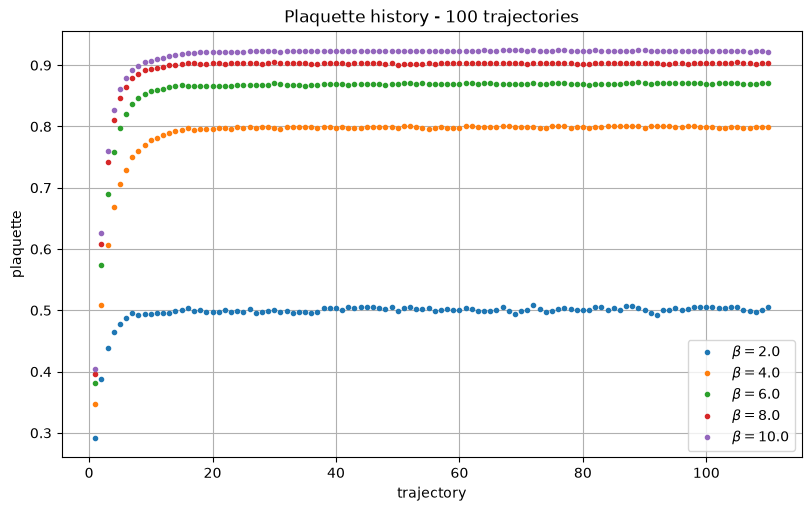

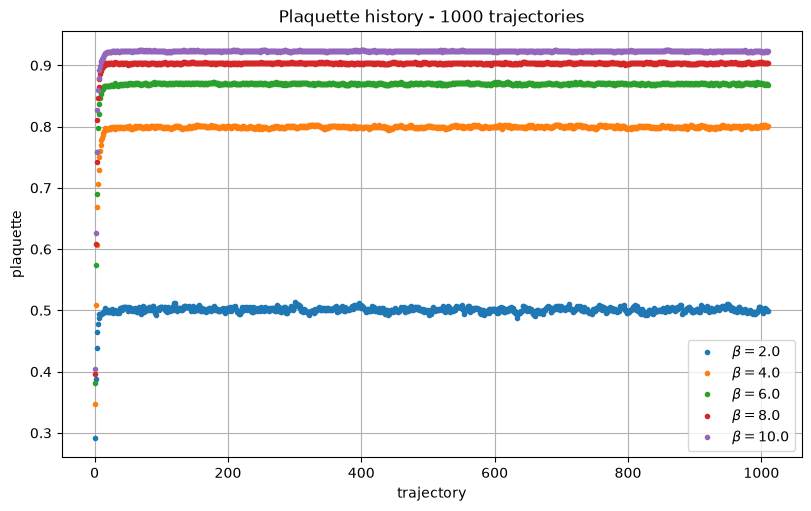

In [12]:
plot_plaquette_history(df_traj100, "Plaquette history - 100 trajectories") #namen der spalten anpassen
plot_plaquette_history(df_traj1000, "Plaquette history - 1000 trajectories")
    

In [13]:
df_phys_traj100 = df_traj100[df_traj100.trajectory > 20] #thermalisieren abschneiden beta scan
df_phys_traj1000 = df_traj1000[df_traj1000.trajectory > 100] #beta scan

df_phys_mdsteps_traj100 = df_mdsteps_traj100[df_mdsteps_traj100.trajectory > 20]
df_phys_mdsteps_traj1000 = df_mdsteps_traj1000[df_mdsteps_traj1000.trajectory > 100]

df_phys_trajL_traj100 = df_trajL_traj100[df_trajL_traj100.trajectory > 20]
df_phys_trajL_traj1000 = df_trajL_traj1000[df_trajL_traj1000.trajectory > 100]

In [14]:
def plot_hist_plaquette(df, beta, bins=30):

    values = df["plaquette"]

    mean = values.mean()
    std = values.std()

    plt.figure(figsize=(8,5))

    plt.hist(
        values,
        bins=bins,
        density=True,
        alpha=0.7,
        rwidth=0.5
    )

    plt.axvline(
        mean,
        linestyle="--",
        label=fr"$\langle P\rangle={mean:.5f}$"
    )

    plt.xlabel(r"$P$")
    plt.ylabel("Probability density")
    plt.title(fr"Plaquette distribution $\beta={beta}$, x axis range 5$\sigma$")
    plt.legend()
    plt.grid()

    plt.xlim(
        mean - 5*std,
        mean + 5*std
    )

    plt.show()

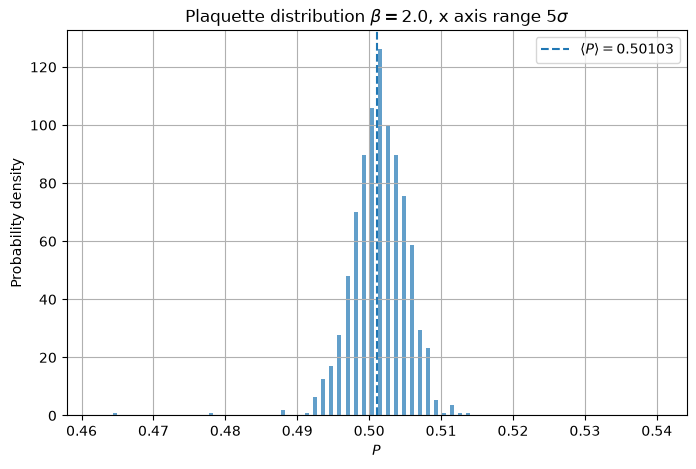

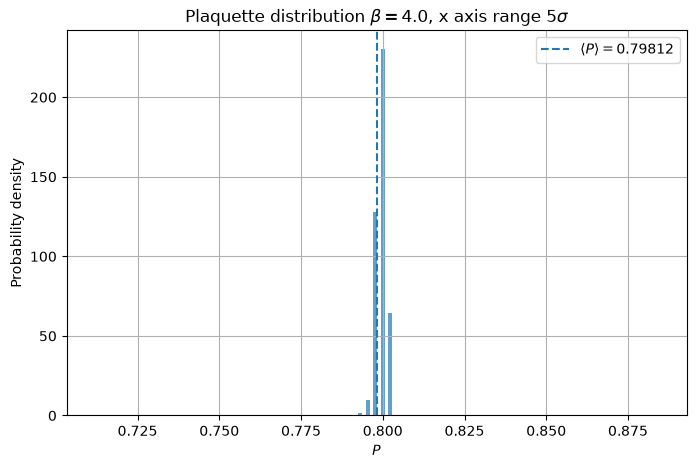

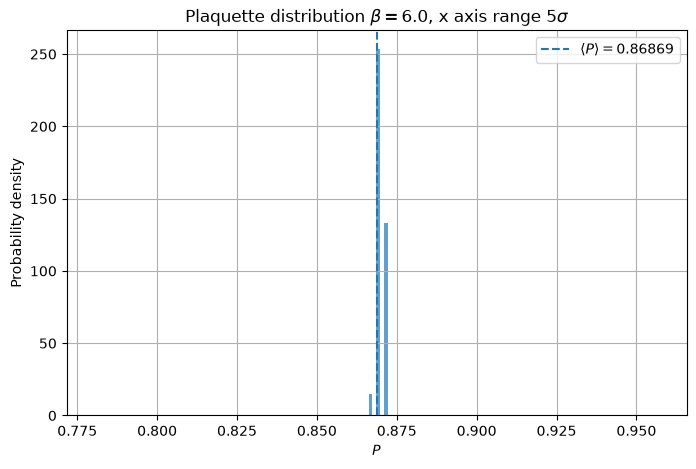

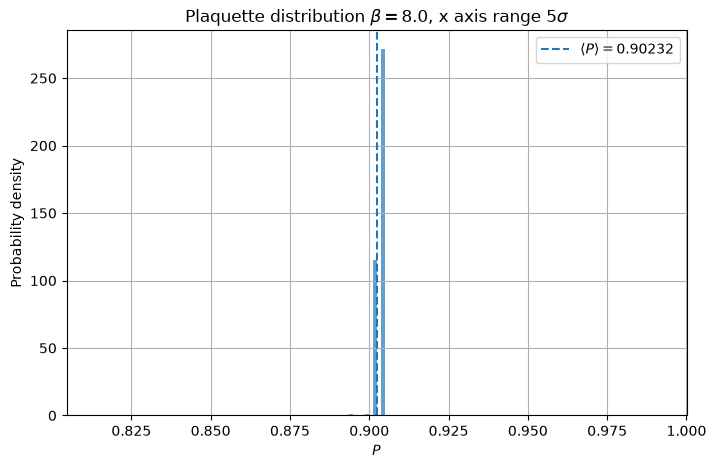

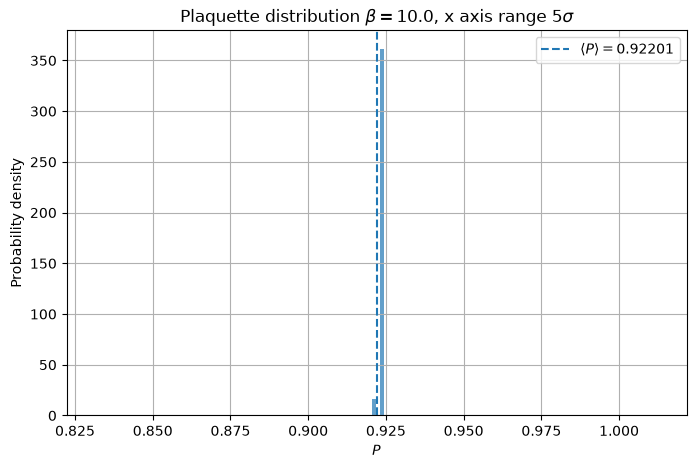

In [15]:
for beta in sorted(df_traj1000.beta.unique()):
    
    subset = df_traj1000[
        df_traj1000.beta == beta
    ]
    
    plot_hist_plaquette(
        subset,
        beta,
        bins=200
    )

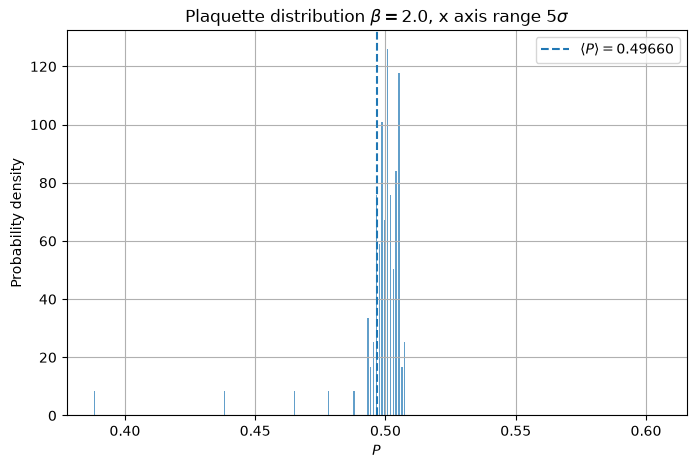

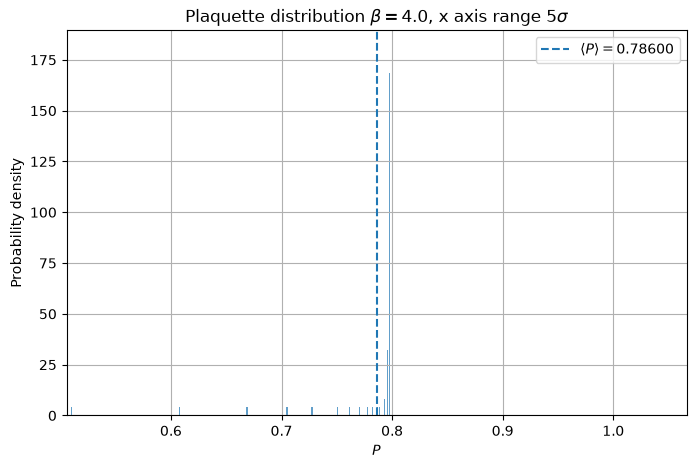

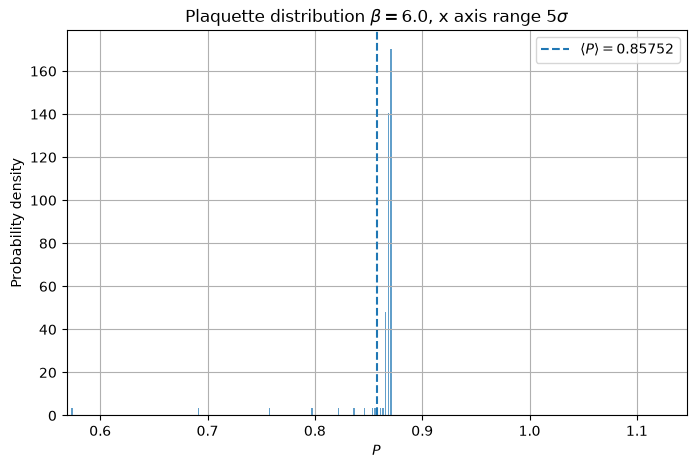

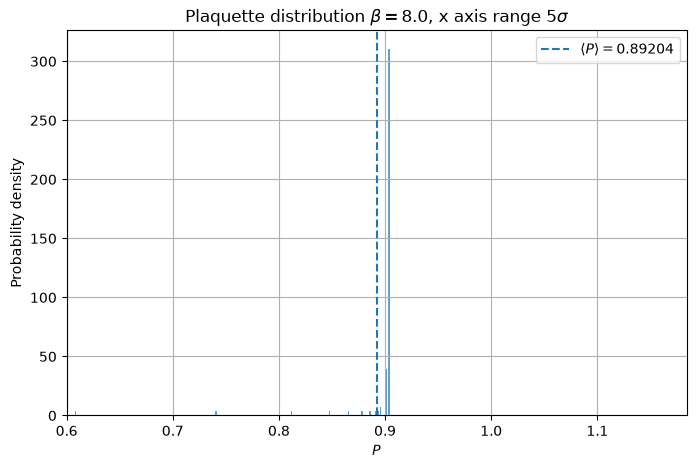

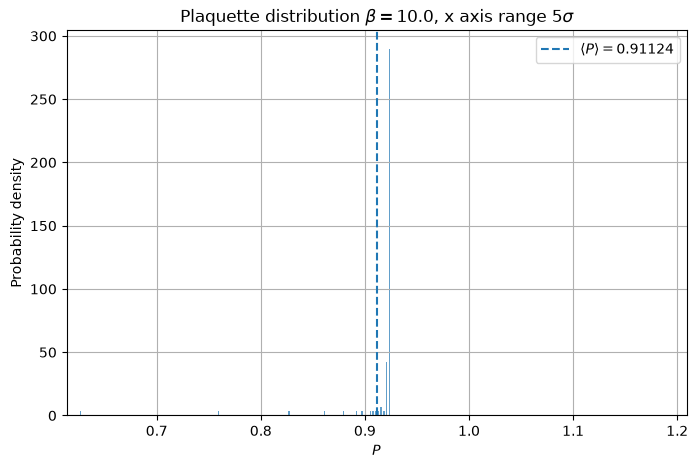

In [16]:
for beta in sorted(df_traj100.beta.unique()):
    
    subset = df_traj100[
        df_traj100.beta == beta
    ]
    
    plot_hist_plaquette(
        subset,
        beta,
        bins=200
    )

In [17]:
def plaq_stats(df):

    stats = (
        df
        .groupby("beta")
        .plaquette
        .agg(
            N="count",
            mean="mean",
            std="std"
        ).sort_index()
    )

    stats["sem"] = stats["std"] / np.sqrt(stats["N"])

    return stats

In [18]:
df_beta2_traj100= df_phys_traj100[df_phys_traj100['beta'] == 2]
df_beta4_traj100= df_phys_traj100[df_phys_traj100['beta'] == 4]
df_beta6_traj100= df_phys_traj100[df_phys_traj100['beta'] == 6]
df_beta8_traj100= df_phys_traj100[df_phys_traj100['beta'] == 8]
df_beta10_traj100= df_phys_traj100[df_phys_traj100['beta'] == 10]


In [19]:
df_beta2_traj1000= df_phys_traj1000[df_phys_traj1000['beta'] == 2]
df_beta4_traj1000= df_phys_traj1000[df_phys_traj1000['beta'] == 4]
df_beta6_traj1000= df_phys_traj1000[df_phys_traj1000['beta'] == 6]
df_beta8_traj1000= df_phys_traj1000[df_phys_traj1000['beta'] == 8]
df_beta10_traj1000= df_phys_traj1000[df_phys_traj1000['beta'] == 10]

In [20]:
def autocorr(df, value, t):
    N = len(df)
    x = df[value].values
    mean = np.mean(x)

    autocorrs = []
    lags = []

    for lag in range(t):
        x1 = x[:N-lag]
        x2 = x[lag:]

        gamma = np.sum((x1 - mean)*(x2 - mean))/(N-lag)

        autocorrs.append(gamma)
        lags.append(lag)

    df_autocorr = pd.DataFrame({
        "lag": lags,
        "autocorr": autocorrs
    })

    # normalize
    df_autocorr["autocorr"] /= df_autocorr["autocorr"].iloc[0]

    return df_autocorr

In [21]:
ac_plaq_beta2_traj100 = autocorr(df_beta2_traj100, "plaquette", 30)
ac_plaq_beta4_traj100 = autocorr(df_beta4_traj100, "plaquette", 30)
ac_plaq_beta6_traj100 = autocorr(df_beta6_traj100, "plaquette", 30)
ac_plaq_beta8_traj100 = autocorr(df_beta8_traj100, "plaquette", 30)
ac_plaq_beta10_traj100 = autocorr(df_beta10_traj100, "plaquette", 30)

In [22]:
ac_plaq_beta2_traj1000 = autocorr(df_beta2_traj1000, "plaquette", 100)
ac_plaq_beta4_traj1000 = autocorr(df_beta4_traj1000, "plaquette", 100)
ac_plaq_beta6_traj1000 = autocorr(df_beta6_traj1000, "plaquette", 100)
ac_plaq_beta8_traj1000 = autocorr(df_beta8_traj1000, "plaquette", 100)
ac_plaq_beta10_traj1000 = autocorr(df_beta10_traj1000, "plaquette", 100)

In [23]:
def plot_autocorr(
    df,
    value,
    ax=None,
    title=None,
    label=None,
    color=None
):

    if ax is None:
        fig, ax = plt.subplots(
            figsize=(8, 5),
            layout="constrained"
        )

    ax.errorbar(
        df["lag"],
        df["autocorr"],
        yerr=df["delta_autocorr"],
        fmt="o",
        markersize=4,
        color=color,
        ecolor=color,
        elinewidth=1.2,
        capsize=3,
        capthick=1.2,
        linestyle="none",
        label=label,
    )

    ax.axhline(
        0,
        linestyle="--",
        linewidth=1,
        alpha=0.5
    )

    ax.set_xlabel(r"$t$")
    ax.set_ylabel(r"$\rho(t)$")

    ax.grid(True, alpha=0.3)

    if title:
        ax.set_title(title)

    return ax

In [24]:
def jackknife_autocorr(df, value, t, n_blocks): #autocorr with jackknife error estimation

    N = len(df)
    block_size = N // n_blocks

    # Berechne die Autokorrelation für das Original-Dataset
    rho_original = autocorr(
        df,
        value,
        t
    )
        
    jackknife_rhos = []

    for i in range(n_blocks):

        start = i * block_size
        end = (
            (i + 1) * block_size
            if i < n_blocks - 1
            else N
        )

        # Daten ohne Block i
        df_jackknife = pd.concat([
            df.iloc[:start],
            df.iloc[end:]
        ])

        # Autokorrelation für dieses Jackknife-Sample
        rho_i = autocorr(
            df_jackknife,
            value,
            t
        )

        jackknife_rhos.append(rho_i)


    rho_jackknife = jackknife_rhos[0].copy()

    # Mittelwert der Jackknife-Samples
    rho_jackknife["autocorr"] = (
        sum(
            rho["autocorr"]
            for rho in jackknife_rhos
        )
        / n_blocks
    )

    variance = np.zeros(t)

    for rho in jackknife_rhos:

        variance += (
            rho["autocorr"].values
            - rho_jackknife["autocorr"].values
        ) ** 2
    #Varianz der Jackknife-Samples
    variance *= (n_blocks - 1) / n_blocks

    delta_rho = np.sqrt(variance)


    result = rho_original.copy()
    result["delta_autocorr"] = delta_rho

    return result

In [25]:
df_rho = jackknife_autocorr(
    df_beta2_traj100,
    "plaquette",
    t=30,
    n_blocks=20
)

print(df_rho.head())

   lag  autocorr  delta_autocorr
0    0  1.000000        0.000000
1    1  0.503215        0.077233
2    2  0.241497        0.175336
3    3  0.100549        0.171882
4    4  0.167818        0.195609


In [26]:
df_beta2_traj100 

,trajectory,plaquette,lattice,beta,mdsteps,trajL,trajectories,checkpoint,file
2370,21,0.496695,8x8x8x8,2.0,10,1.0,100,5,L8x8x8x8_beta2_md10_trajL1.0_traj100_ckpt5.log
2371,22,0.501110,8x8x8x8,2.0,10,1.0,100,5,L8x8x8x8_beta2_md10_trajL1.0_traj100_ckpt5.log
2372,23,0.497178,8x8x8x8,2.0,10,1.0,100,5,L8x8x8x8_beta2_md10_trajL1.0_traj100_ckpt5.log
2373,24,0.499592,8x8x8x8,2.0,10,1.0,100,5,L8x8x8x8_beta2_md10_trajL1.0_traj100_ckpt5.log
2374,25,0.497745,8x8x8x8,2.0,10,1.0,100,5,L8x8x8x8_beta2_md10_trajL1.0_traj100_ckpt5.log
...,...,...,...,...,...,...,...,...,...
2455,106,0.500795,8x8x8x8,2.0,10,1.0,100,5,L8x8x8x8_beta2_md10_trajL1.0_traj100_ckpt5.log
2456,107,0.498184,8x8x8x8,2.0,10,1.0,100,5,L8x8x8x8_beta2_md10_trajL1.0_traj100_ckpt5.log
2457,108,0.497491,8x8x8x8,2.0,10,1.0,100,5,L8x8x8x8_beta2_md10_trajL1.0_traj100_ckpt5.log
2458,109,0.499997,8x8x8x8,2.0,10,1.0,100,5,L8x8x8x8_beta2_md10_trajL1.0_traj100_ckpt5.log


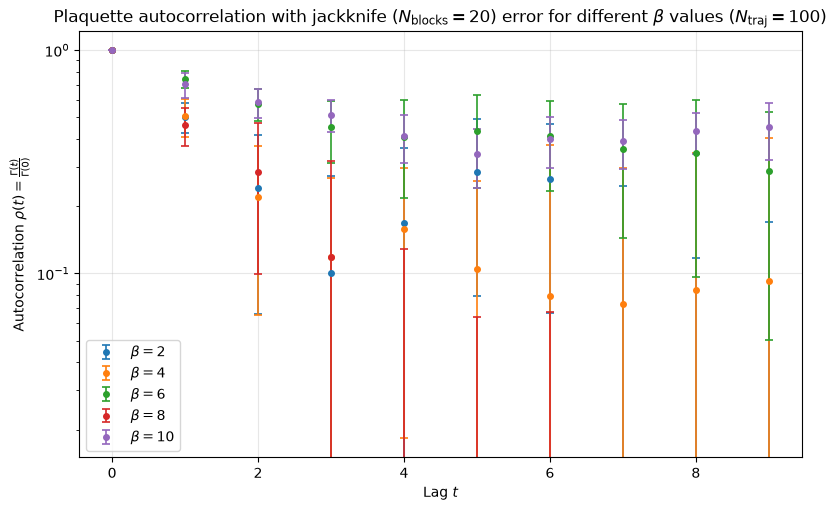

In [27]:
fig, ax = plt.subplots(figsize=(8,5), layout="constrained")

plot_autocorr(jackknife_autocorr(df_beta2_traj100, "plaquette",t=10,n_blocks=20), "plaquette", ax=ax, label=r"$\beta=2$")
plot_autocorr(jackknife_autocorr(df_beta4_traj100, "plaquette",t=10,n_blocks=20), "plaquette", ax=ax, label=r"$\beta=4$")
plot_autocorr(jackknife_autocorr(df_beta6_traj100, "plaquette",t=10,n_blocks=20), "plaquette", ax=ax, label=r"$\beta=6$")
plot_autocorr(jackknife_autocorr(df_beta8_traj100, "plaquette",t=10,n_blocks=20), "plaquette", ax=ax, label=r"$\beta=8$")
plot_autocorr(jackknife_autocorr(df_beta10_traj100, "plaquette",t=10,n_blocks=20), "plaquette", ax=ax, label=r"$\beta=10$")

ax.legend()

plt.title(r"Plaquette autocorrelation with jackknife ($N_{\text{blocks}}=20$) error for different $\beta$ values ($N_{\text{traj}}=100$)")
plt.xlabel("Lag $t$")
plt.ylabel(r"Autocorrelation $\rho(t)=\frac{\Gamma(t)}{\Gamma(0)}$")
plt.yscale("log")
plt.show()

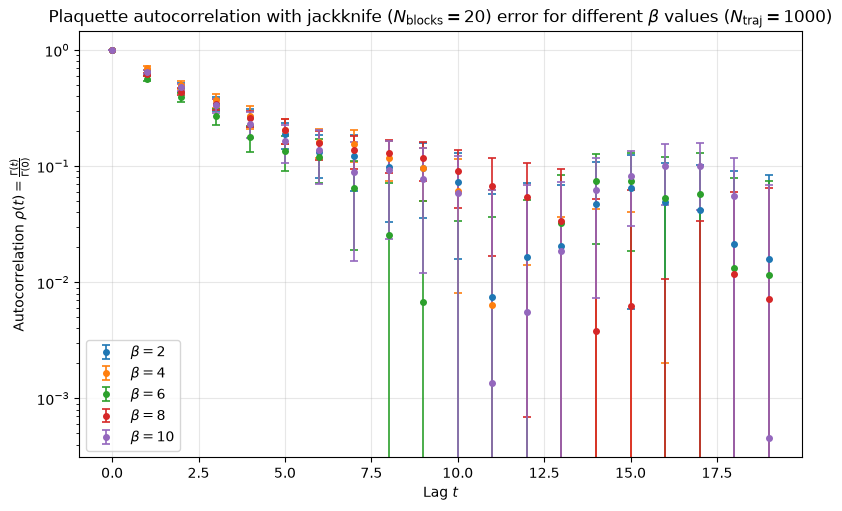

In [28]:
fig, ax = plt.subplots(figsize=(8,5), layout="constrained")

plot_autocorr(jackknife_autocorr(df_beta2_traj1000, "plaquette",t=20,n_blocks=20), "plaquette", ax=ax, label=r"$\beta=2$")
plot_autocorr(jackknife_autocorr(df_beta4_traj1000, "plaquette",t=20,n_blocks=20), "plaquette", ax=ax, label=r"$\beta=4$")
plot_autocorr(jackknife_autocorr(df_beta6_traj1000, "plaquette",t=20,n_blocks=20), "plaquette", ax=ax, label=r"$\beta=6$")
plot_autocorr(jackknife_autocorr(df_beta8_traj1000, "plaquette",t=20,n_blocks=20), "plaquette", ax=ax, label=r"$\beta=8$")
plot_autocorr(jackknife_autocorr(df_beta10_traj1000, "plaquette",t=20,n_blocks=20), "plaquette", ax=ax, label=r"$\beta=10$")

ax.legend()

plt.title(r"Plaquette autocorrelation with jackknife ($N_{\text{blocks}}=20$) error for different $\beta$ values ($N_{\text{traj}}=1000$)")
plt.xlabel("Lag $t$")
plt.ylabel(r"Autocorrelation $\rho(t)=\frac{\Gamma(t)}{\Gamma(0)}$")
plt.yscale("log")
plt.show()

In [29]:
import numpy as np
import pandas as pd


def bootstrap_autocorr(df, value, t, block_size, n_bootstrap):

    N = len(df)

    # --------------------------------------------------
    # 1. ORIGINAL autocorrelation
    #    Uses ALL of the original HMC data
    # --------------------------------------------------
    rho_original = autocorr(df, value, t)

    # --------------------------------------------------
    # 2. Create complete blocks for the bootstrap
    # --------------------------------------------------
    n_blocks = N // block_size

    if n_blocks < 2:
        raise ValueError("block_size is too large.")

    N_used = n_blocks * block_size

    df_blocks = df.iloc[:N_used].copy()

    blocks = [
        df_blocks.iloc[
            i * block_size:(i + 1) * block_size
        ].copy()
        for i in range(n_blocks)
    ]

    # --------------------------------------------------
    # 3. Bootstrap
    # --------------------------------------------------
    bootstrap_rhos = []

    for _ in range(n_bootstrap):

        indices = np.random.randint(
            0,
            n_blocks,
            size=n_blocks
        )

        df_bootstrap = pd.concat(
            [blocks[i] for i in indices],
            ignore_index=True
        )

        rho_bootstrap = autocorr(
            df_bootstrap,
            value,
            t
        )

        bootstrap_rhos.append(
            rho_bootstrap["autocorr"].to_numpy()
        )

    # --------------------------------------------------
    # 4. Bootstrap error
    # --------------------------------------------------
    bootstrap_rhos = np.asarray(bootstrap_rhos)

    delta_rho = np.std(
        bootstrap_rhos,
        axis=0,
        ddof=1
    )

    # --------------------------------------------------
    # 5. Attach error to ORIGINAL rho
    # --------------------------------------------------
    result = rho_original.copy()

    result["delta_autocorr"] = delta_rho

    return result

In [30]:
print(bootstrap_autocorr(df_beta2_traj1000, "plaquette",t=20,block_size = 50,n_bootstrap=100).head(15))
print(jackknife_autocorr(df_beta2_traj1000, "plaquette",t=20,n_blocks=20).head(15))

    lag  autocorr  delta_autocorr
0     0  1.000000        0.000000
1     1  0.646468        0.028067
2     2  0.478607        0.046343
3     3  0.344230        0.056598
4     4  0.264647        0.058638
5     5  0.188182        0.058163
6     6  0.131843        0.054278
7     7  0.122824        0.055088
8     8  0.098531        0.054386
9     9  0.096730        0.053493
10   10  0.072647        0.053315
11   11  0.007472        0.050782
12   12  0.016592        0.047137
13   13  0.020450        0.046505
14   14  0.047233        0.048160
    lag  autocorr  delta_autocorr
0     0  1.000000        0.000000
1     1  0.646468        0.026649
2     2  0.478607        0.039666
3     3  0.344230        0.046994
4     4  0.264647        0.046936
5     5  0.188182        0.048588
6     6  0.131843        0.052441
7     7  0.122824        0.061623
8     8  0.098531        0.065486
9     9  0.096730        0.061114
10   10  0.072647        0.056650
11   11  0.007472        0.050023
12   12  0.016

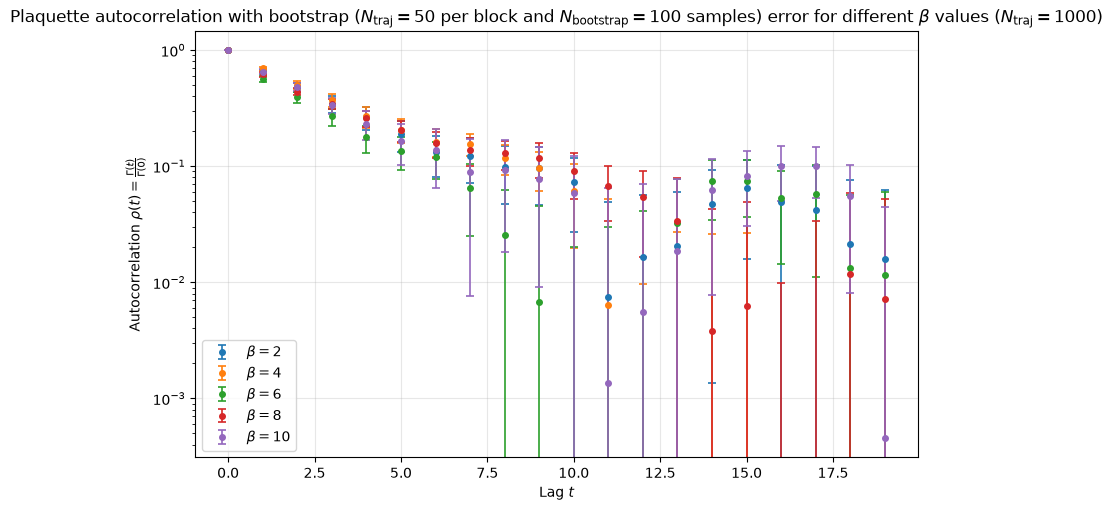

In [32]:
fig, ax = plt.subplots(figsize=(8,5), layout="constrained")

plot_autocorr(bootstrap_autocorr(df_beta2_traj1000, "plaquette",t=20,block_size = 50,n_bootstrap=100), "plaquette", ax=ax, label=r"$\beta=2$")
plot_autocorr(bootstrap_autocorr(df_beta4_traj1000, "plaquette",t=20,block_size = 50,n_bootstrap=100), "plaquette", ax=ax, label=r"$\beta=4$")
plot_autocorr(bootstrap_autocorr(df_beta6_traj1000, "plaquette",t=20,block_size = 50,n_bootstrap=100), "plaquette", ax=ax, label=r"$\beta=6$")
plot_autocorr(bootstrap_autocorr(df_beta8_traj1000, "plaquette",t=20,block_size = 50,n_bootstrap=100), "plaquette", ax=ax, label=r"$\beta=8$")
plot_autocorr(bootstrap_autocorr(df_beta10_traj1000, "plaquette",t=20,block_size = 50,n_bootstrap=100), "plaquette", ax=ax, label=r"$\beta=10$")

ax.legend()

plt.title(r"Plaquette autocorrelation with bootstrap ($N_{\text{traj}}=50$ per block and $N_{\text{bootstrap}}=100$ samples) error for different $\beta$ values ($N_{\text{traj}}=1000$)")
plt.xlabel("Lag $t$")
plt.ylabel(r"Autocorrelation $\rho(t)=\frac{\Gamma(t)}{\Gamma(0)}$")
plt.yscale("log")
plt.show()

In [129]:
def integrated_autocorr_time(df, value, W): #integrated autocorrelation time, W = window size

    ac_df = autocorr(df, value, W+1)

    tau_int = 0.5 + np.sum(ac_df["autocorr"][1:])

    return tau_int

In [130]:
def integrated_autocorr_time_scan(df, value, W):

    N = len(df)

    ac_df = autocorr(df, value, W + 1)

    tau_ints = []
    delta_taus = []

    for w in range(1, W + 1):

        tau_int = 0.5 + np.sum(
            ac_df["autocorr"][1:w + 1]
        )

        # Wolff error formula
        argument = w + 0.5 - tau_int

        if argument > 0:
            delta_tau = (
                2 * tau_int
                * np.sqrt(argument / N)
            )
        else:
            delta_tau = np.nan

        tau_ints.append(tau_int)
        delta_taus.append(delta_tau)

    return pd.DataFrame({
        "W": range(1, W + 1),
        "tau_int": tau_ints,
        "delta_tau": delta_taus
    })

In [131]:
int_act_scan_beta2_traj100 =integrated_autocorr_time_scan(df_beta2_traj100, "plaquette", 30)
int_act_scan_beta4_traj100 =integrated_autocorr_time_scan(df_beta4_traj100, "plaquette", 30)
int_act_scan_beta6_traj100 =integrated_autocorr_time_scan(df_beta6_traj100, "plaquette", 30)
int_act_scan_beta8_traj100 =integrated_autocorr_time_scan(df_beta8_traj100, "plaquette", 30)
int_act_scan_beta10_traj100 =integrated_autocorr_time_scan(df_beta10_traj100, "plaquette", 30)

In [132]:
int_act_scan_beta2_traj1000 =integrated_autocorr_time_scan(df_beta2_traj1000, "plaquette", 30)
int_act_scan_beta4_traj1000 =integrated_autocorr_time_scan(df_beta4_traj1000, "plaquette", 30)
int_act_scan_beta6_traj1000 =integrated_autocorr_time_scan(df_beta6_traj1000, "plaquette", 30)
int_act_scan_beta8_traj1000 =integrated_autocorr_time_scan(df_beta8_traj1000, "plaquette", 30)
int_act_scan_beta10_traj1000 =integrated_autocorr_time_scan(df_beta10_traj1000, "plaquette", 30)

In [133]:
print(int_act_scan_beta2_traj100.head(10))

    W   tau_int  delta_tau
0   1  1.003215   0.149069
1   2  1.244712   0.294001
2   3  1.345261   0.416306
3   4  1.513079   0.551293
4   5  1.797625   0.729202
5   6  2.063529   0.916301
6   7  2.040352   1.005070
7   8  1.888672   1.023787
8   9  1.761070   1.032823
9  10  1.830769   1.136403


In [134]:
def plot_int_autocorr(
    df,
    ax=None,
    title=None,
    label=None,
    color=None
):

    if ax is None:
        fig, ax = plt.subplots(
            figsize=(8, 5),
            layout="constrained"
        )

    # -------------------------
    # tau_int(W)
    # -------------------------

    ax.plot(
        df["W"],
        df["tau_int"],
        ".-",
        color=color,
        label=label,
        linewidth=1.5,
        markersize=4
    )

    # -------------------------
    # Fehlerband
    # -------------------------

    valid = (
        df["delta_tau"].notna()
        & (df["delta_tau"] >= 0)
    )

    ax.fill_between(
        df.loc[valid, "W"],
        df.loc[valid, "tau_int"]
        - df.loc[valid, "delta_tau"],
        df.loc[valid, "tau_int"]
        + df.loc[valid, "delta_tau"],
        color=color,
        alpha=0.2
    )

    # -------------------------
    # labels
    # -------------------------

    ax.set_xlabel(r"$W$")
    ax.set_ylabel(r"$\tau_{\mathrm{int}}(W)$")

    ax.grid(True, alpha=0.3)

    if title:
        ax.set_title(title)

    return ax

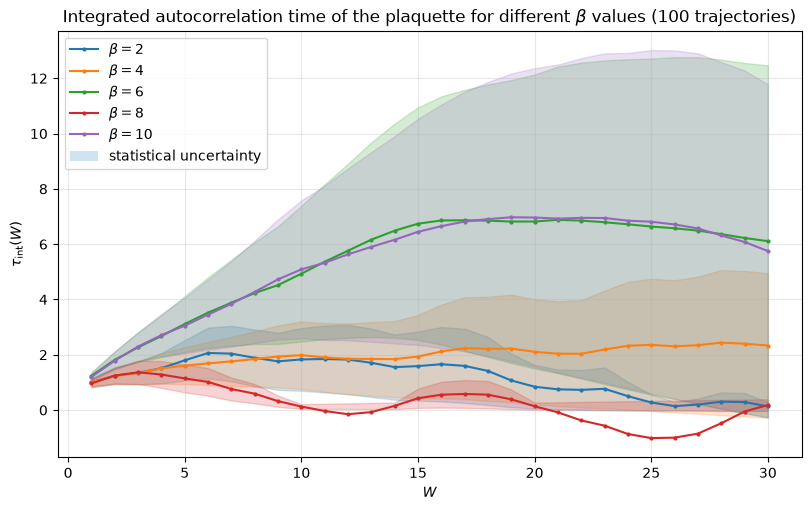

In [135]:
from matplotlib.patches import Patch

fig, ax = plt.subplots(
    figsize=(8, 5),
    layout="constrained"
)

plot_int_autocorr(
    int_act_scan_beta2_traj100,
    ax=ax,
    label=r"$\beta=2$",
    color="tab:blue"
)

plot_int_autocorr(
    int_act_scan_beta4_traj100,
    ax=ax,
    label=r"$\beta=4$",
    color="tab:orange"
)

plot_int_autocorr(
    int_act_scan_beta6_traj100,
    ax=ax,
    label=r"$\beta=6$",
    color="tab:green"
)

plot_int_autocorr(
    int_act_scan_beta8_traj100,
    ax=ax,
    label=r"$\beta=8$",
    color="tab:red"
)

plot_int_autocorr(
    int_act_scan_beta10_traj100,
    ax=ax,
    label=r"$\beta=10$",
    color="tab:purple"
)

# Dummy handle für das Fehlerband
uncertainty_patch = Patch(
    alpha=0.2,
    label=r"statistical uncertainty"
)

handles, labels = ax.get_legend_handles_labels()

ax.legend(
    handles + [uncertainty_patch],
    labels + [r"statistical uncertainty"]
)

ax.set_title(
    r"Integrated autocorrelation time of the plaquette "
    r"for different $\beta$ values (100 trajectories)"
)

plt.show()

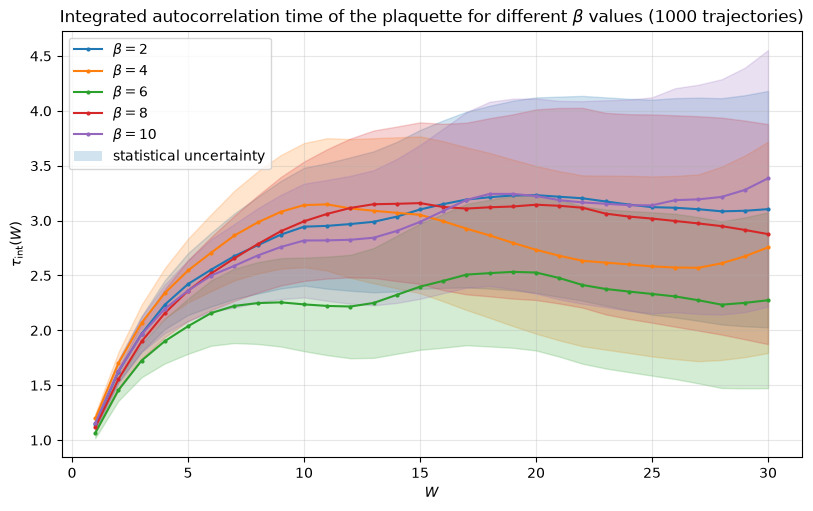

In [136]:
from matplotlib.patches import Patch

fig, ax = plt.subplots(
    figsize=(8, 5),
    layout="constrained"
)

plot_int_autocorr(
    int_act_scan_beta2_traj1000,
    ax=ax,
    label=r"$\beta=2$",
    color="tab:blue"
)

plot_int_autocorr(
    int_act_scan_beta4_traj1000,
    ax=ax,
    label=r"$\beta=4$",
    color="tab:orange"
)

plot_int_autocorr(
    int_act_scan_beta6_traj1000,
    ax=ax,
    label=r"$\beta=6$",
    color="tab:green"
)

plot_int_autocorr(
    int_act_scan_beta8_traj1000,
    ax=ax,
    label=r"$\beta=8$",
    color="tab:red"
)

plot_int_autocorr(
    int_act_scan_beta10_traj1000,
    ax=ax,
    label=r"$\beta=10$",
    color="tab:purple"
)

# Dummy handle für das Fehlerband
uncertainty_patch = Patch(
    alpha=0.2,
    label=r"statistical uncertainty"
)

handles, labels = ax.get_legend_handles_labels()

ax.legend(
    handles + [uncertainty_patch],
    labels + [r"statistical uncertainty"]
)

ax.set_title(
    r"Integrated autocorrelation time of the plaquette "
    r"for different $\beta$ values (1000 trajectories)"
)

plt.show()

In [137]:
def tau_exp_from_tau_int(tau_int, S=1):

    tau_exp = np.zeros_like(tau_int)

    for i, tau in enumerate(tau_int):

        if tau <= 0.5:
            tau_exp[i] = 1e-10

        else:
            tau_exp[i] = S / np.log(
                (2*tau + 1) /
                (2*tau - 1)
            )

    return tau_exp

In [138]:
def window(tau_exp, N):

    g = []

    for W in range(1, len(tau_exp)):

        value = (
            np.exp(-W/tau_exp[W])
            -
            tau_exp[W]/(np.sqrt(W)*N)
        )

        g.append(value)

    return np.array(g)

In [139]:
def find_optimal_W(df, value, Wmax, S=1):

    N = len(df)

    tau_int_df = integrated_autocorr_time_scan(df, value, Wmax)

    tau_int = tau_int_df["tau_int"].values
    delta_tau = tau_int_df["delta_tau"].values

    tau_exp = tau_exp_from_tau_int(tau_int, S)

    g = window(tau_exp, N)

    # erstes W mit g(W)<0
    for W in range(len(g)):

        if g[W] < 0:
            W_opt = W+1
            break

    return {
        "W": W_opt,
        "tau_int": tau_int[W_opt],
        "delta_tau": delta_tau[W_opt],
        "tau_exp": tau_exp[W_opt],
    }

In [140]:
print(find_optimal_W(df_beta2_traj100, "plaquette", 40))
print(find_optimal_W(df_beta4_traj100, "plaquette", 40))
print(find_optimal_W(df_beta6_traj100, "plaquette", 40))
print(find_optimal_W(df_beta8_traj100, "plaquette", 40))
print(find_optimal_W(df_beta10_traj100, "plaquette", 40))

{'W': 9, 'tau_int': np.float64(1.830768743082902), 'delta_tau': np.float64(1.1364033991468176), 'tau_exp': np.float64(1.7843079698692401)}
{'W': 10, 'tau_int': np.float64(1.9023683359573118), 'delta_tau': np.float64(1.2424685056937796), 'tau_exp': np.float64(1.8577257690678468)}
{'W': 28, 'tau_int': np.float64(6.223263673483502), 'delta_tau': np.float64(6.329770827543882), 'tau_exp': np.float64(6.209849929239771)}
{'W': 5, 'tau_int': np.float64(1.0169397762281744), 'delta_tau': np.float64(0.5020136008505619), 'tau_exp': np.float64(0.9289157456988404)}
{'W': 28, 'tau_int': np.float64(6.079449490521582), 'delta_tau': np.float64(6.202568155255552), 'tau_exp': np.float64(6.065717296145197)}


In [141]:
print(find_optimal_W(df_beta2_traj1000, "plaquette", 200))
print(find_optimal_W(df_beta4_traj1000, "plaquette", 200))
print(find_optimal_W(df_beta6_traj1000, "plaquette", 200))
print(find_optimal_W(df_beta8_traj1000, "plaquette", 200))
print(find_optimal_W(df_beta10_traj1000, "plaquette", 200))

{'W': 23, 'tau_int': np.float64(3.1463302136642373), 'delta_tau': np.float64(0.9639396875405536), 'tau_exp': np.float64(3.1196635649589703)}
{'W': 20, 'tau_int': np.float64(2.679939911182599), 'delta_tau': np.float64(0.7708055958756277), 'tau_exp': np.float64(2.6485506647629724)}
{'W': 19, 'tau_int': np.float64(2.527024819362575), 'delta_tau': np.float64(0.7102787049809325), 'tau_exp': np.float64(2.493696449352725)}
{'W': 23, 'tau_int': np.float64(3.037077929877401), 'delta_tau': np.float64(0.9328453686007198), 'tau_exp': np.float64(3.0094380920455372)}
{'W': 23, 'tau_int': np.float64(3.140366956459932), 'delta_tau': np.float64(0.9622470584031778), 'tau_exp': np.float64(3.113648972537237)}


In [142]:
def autocorr_error(df, value, groupby, Wmax, S=1):

    results = []

    for group, group_df in df.groupby(groupby):

        N = len(group_df)

        # Wolff analysis
        result = find_optimal_W(group_df, value, Wmax, S)

        tau_int = result["tau_int"]
        delta_tau = result["delta_tau"]
        tau_exp = result["tau_exp"]
        W_opt = result["W"]

        gamma0 = np.var(group_df[value].values, ddof=0)

        sigma = np.sqrt(
            2 * tau_int * gamma0 / N
        )

        results.append({
            groupby: group,
            "tau_int": tau_int, 
            "delta_tau": delta_tau,
            "tau_exp": tau_exp,
            "W_opt": W_opt,
            "gamma0": gamma0,
            "sem_autocorr": sigma
        })

    return pd.DataFrame(results)

In [143]:
plaq_error_traj100 = autocorr_error(df_traj100, "plaquette", "beta", 40)
plaq_error_traj1000 = autocorr_error(df_traj1000, "plaquette", "beta", 40)

In [144]:
df_mdstep5_traj100 =df_phys_mdsteps_traj100[df_phys_mdsteps_traj100.mdsteps == 5] 
df_mdstep8_traj100 =df_phys_mdsteps_traj100[df_phys_mdsteps_traj100.mdsteps == 8]
df_mdstep10_traj100 = df_phys_mdsteps_traj100[df_phys_mdsteps_traj100.mdsteps == 10]
df_mdstep20_traj100 = df_phys_mdsteps_traj100[df_phys_mdsteps_traj100.mdsteps == 20]

df_mdstep5_traj1000 =df_phys_mdsteps_traj1000[df_phys_mdsteps_traj1000.mdsteps == 5] 
df_mdstep8_traj1000 =df_phys_mdsteps_traj1000[df_phys_mdsteps_traj1000.mdsteps == 8]
df_mdstep10_traj1000 = df_phys_mdsteps_traj1000[df_phys_mdsteps_traj1000.mdsteps == 10]
df_mdstep20_traj1000 = df_phys_mdsteps_traj1000[df_phys_mdsteps_traj1000.mdsteps == 20]

df_trajL05_traj100 = df_phys_trajL_traj100[df_phys_trajL_traj100.trajL == 0.5]
df_trajL1_traj100 = df_phys_trajL_traj100[df_phys_trajL_traj100.trajL == 1.0]
df_trajL125_traj100 = df_phys_trajL_traj100[df_phys_trajL_traj100.trajL == 1.25]
df_trajL2_traj100 = df_phys_trajL_traj100[df_phys_trajL_traj100.trajL == 2.0]

df_trajL05_traj1000 = df_phys_trajL_traj1000[df_phys_trajL_traj1000.trajL == 0.5]
df_trajL1_traj1000 = df_phys_trajL_traj1000[df_phys_trajL_traj1000.trajL == 1.0]
df_trajL125_traj1000 = df_phys_trajL_traj1000[df_phys_trajL_traj1000.trajL == 1.25]
df_trajL2_traj1000 = df_phys_trajL_traj1000[df_phys_trajL_traj1000.trajL == 2.0]

In [145]:
def measurement_stats(df, value, groupby):

    stats = (
        df
        .groupby(groupby)[value]
        .agg(
            N="count",
            mean="mean",
            std="std"
        )
        .sort_index()
    )

    stats["sem"] = stats["std"] / np.sqrt(stats["N"])

    return stats.reset_index()

In [146]:
df_plaq_traj100= measurement_stats(df_phys_traj100, "plaquette", "beta")
df_plaq_traj1000= measurement_stats(df_phys_traj1000, "plaquette", "beta")

df_plaq_mdsteps_traj100= measurement_stats(df_phys_mdsteps_traj100, "plaquette", "mdsteps")
df_plaq_mdsteps_traj1000= measurement_stats(df_phys_mdsteps_traj1000, "plaquette", "mdsteps")

df_plaq_trajL_traj100= measurement_stats(df_phys_trajL_traj100, "plaquette", "trajL")
df_plaq_trajL_traj1000= measurement_stats(df_phys_trajL_traj1000, "plaquette", "trajL")

In [147]:
stats_traj100 = measurement_stats(df_phys_traj100, "plaquette", "beta")
corr_traj100 = autocorr_error(df_phys_traj100, "plaquette", "beta", Wmax=90)

df_plaq_traj100 = stats_traj100.merge(corr_traj100, on="beta")

stats_traj1000 = measurement_stats(df_phys_traj1000, "plaquette", "beta")
corr_traj1000 = autocorr_error(df_phys_traj1000, "plaquette", "beta", Wmax=900)

df_plaq_traj1000 = stats_traj1000.merge(corr_traj1000, on="beta")

stats_mdsteps_traj100 = measurement_stats(df_phys_mdsteps_traj100, "plaquette", "mdsteps")
corr_mdsteps_traj100 = autocorr_error(df_phys_mdsteps_traj100, "plaquette", "mdsteps", Wmax=90)

df_plaq_mdsteps_traj100 = stats_mdsteps_traj100.merge(corr_mdsteps_traj100, on="mdsteps")


stats_mdsteps_traj1000 = measurement_stats(df_phys_mdsteps_traj1000, "plaquette", "mdsteps")
corr_mdsteps_traj1000 = autocorr_error(df_phys_mdsteps_traj1000, "plaquette", "mdsteps", Wmax=900)

df_plaq_mdsteps_traj1000 = stats_mdsteps_traj1000.merge(corr_mdsteps_traj1000, on="mdsteps")


stats_trajL_traj100 = measurement_stats(df_phys_trajL_traj100, "plaquette", "trajL")
corr_trajL_traj100 = autocorr_error(df_phys_trajL_traj100, "plaquette", "trajL", Wmax=90)

df_plaq_trajL_traj100 = stats_trajL_traj100.merge(corr_trajL_traj100, on="trajL")


stats_trajL_traj1000 = measurement_stats(df_phys_trajL_traj1000, "plaquette", "trajL")
corr_trajL_traj1000 = autocorr_error(df_phys_trajL_traj1000, "plaquette", "trajL", Wmax=900)

df_plaq_trajL_traj1000 = stats_trajL_traj1000.merge(corr_trajL_traj1000, on="trajL")


/var/folders/gn/0cpq6tpx3mb7dr15cprkp6s00000gn/T/ipykernel_73700/1981697336.py:13: RuntimeWarning: invalid value encountered in scalar divide
  gamma = np.sum((x1 - mean)*(x2 - mean))/(N-lag)


In [148]:
latex_table_plaq_traj100 = df_plaq_traj100.to_latex(index=False) 
latex_table_plaq_traj1000 = df_plaq_traj1000.to_latex(index=False)

latex_table_plaq_mdsteps_traj100 = df_plaq_mdsteps_traj100.to_latex(index=False) 
latex_table_plaq_mdsteps_traj1000 = df_plaq_mdsteps_traj1000.to_latex(index=False)

latex_table_plaq_trajL_traj100 = df_plaq_trajL_traj100.to_latex(index=False) 
latex_table_plaq_trajL_traj1000 = df_plaq_trajL_traj1000.to_latex(index=False)


print(latex_table_plaq_traj100)
print(latex_table_plaq_traj1000)

print(latex_table_plaq_mdsteps_traj100)
print(latex_table_plaq_mdsteps_traj1000)

print(latex_table_plaq_trajL_traj100)
print(latex_table_plaq_trajL_traj1000)

\begin{tabular}{rrrrrrrrrrr}
\toprule
beta & N & mean & std & sem & tau_int & delta_tau & tau_exp & W_opt & gamma0 & sem_autocorr \\
\midrule
2.000000 & 90 & 0.501305 & 0.003287 & 0.000346 & 1.830769 & 1.136403 & 1.784308 & 9 & 0.000011 & 0.000659 \\
4.000000 & 90 & 0.799032 & 0.001182 & 0.000125 & 1.902368 & 1.242469 & 1.857726 & 10 & 0.000001 & 0.000242 \\
6.000000 & 90 & 0.869522 & 0.001250 & 0.000132 & 6.223264 & 6.329771 & 6.209850 & 28 & 0.000002 & 0.000462 \\
8.000000 & 90 & 0.903327 & 0.000695 & 0.000073 & 1.016940 & 0.502014 & 0.928916 & 5 & 0.000000 & 0.000104 \\
10.000000 & 90 & 0.923347 & 0.000681 & 0.000072 & 6.079449 & 6.202568 & 6.065717 & 28 & 0.000000 & 0.000249 \\
\bottomrule
\end{tabular}

\begin{tabular}{rrrrrrrrrrr}
\toprule
beta & N & mean & std & sem & tau_int & delta_tau & tau_exp & W_opt & gamma0 & sem_autocorr \\
\midrule
2.000000 & 910 & 0.501585 & 0.003472 & 0.000115 & 3.146330 & 0.963940 & 3.119664 & 23 & 0.000012 & 0.000289 \\
4.000000 & 910 & 0.799586 & 0

In [149]:
def plot_plaquette_avr_beta(df, trajectories=None):

    plt.figure(figsize=(8,5))

    dx = 0.01

    # Naiver Fehler
    plt.errorbar(
        df["beta"] - dx,
        df["mean"],
        yerr=df["sem"],
        fmt="o",
        capsize=3,
        label="Naiver Fehler"
    )

    # Wolff-Fehler
    plt.errorbar(
        df["beta"] + dx,
        df["mean"],
        yerr=df["sem_autocorr"],
        fmt="s",
        capsize=3,
        label="Autokorrelations-korrigiert"
    )

    plt.xlabel(r"$\beta$")
    plt.ylabel(r"$\langle P\rangle$")

    if trajectories is not None:
        plt.title(
            rf"$\langle P\rangle$ vs $\beta$: {trajectories} trajectories"
        )
    else:
        plt.title(r"$\langle P\rangle$ vs $\beta$")

    plt.legend()
    plt.grid()
    plt.show()

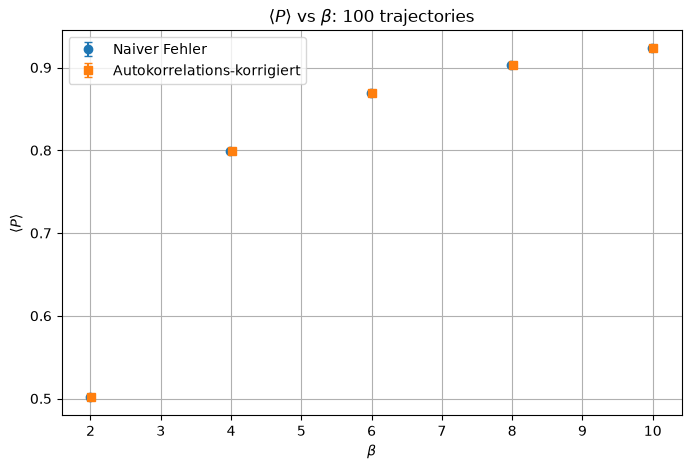

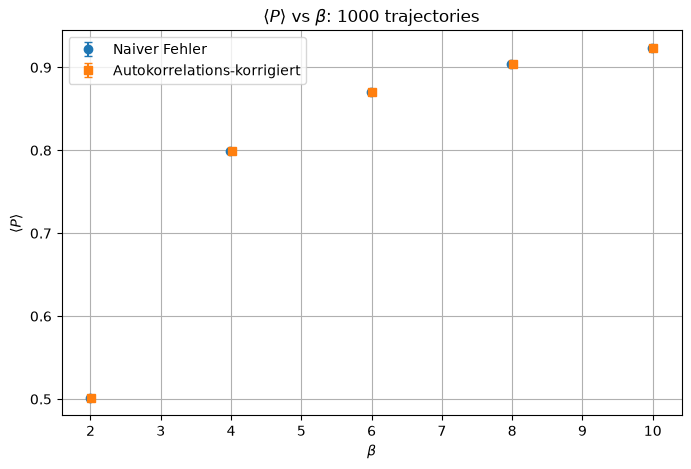

In [150]:
plot_plaquette_avr_beta(df_plaq_traj100, trajectories=100)
plot_plaquette_avr_beta(df_plaq_traj1000, trajectories=1000)

In [151]:
import re

def parse_acceptance(logfile):

    data = []

    with open(logfile) as f:
        trajectory = 0

        for line in f:

            if "Metropolis_test -- ACCEPTED" in line:
                trajectory += 1
                data.append({
                    "trajectory": trajectory,
                    "accepted": 1
                })

            elif "Metropolis_test -- REJECTED" in line:
                trajectory += 1
                data.append({
                    "trajectory": trajectory,
                    "accepted": 0
                })

    return data

In [152]:
measurements = []

for log in logs:

    params = parse_log_name(log)

    acc = parse_acceptance(log)

    for a in acc:
        a.update(params)
        measurements.append(a)

df_acc = pd.DataFrame(measurements)

In [153]:
df_acc_beta_scan = df_acc[
    (df_acc.mdsteps == 10) &
    (df_acc.trajL == 1.0) &
    (df_acc.beta != 5.6)
]

In [154]:
df_acc_100 = df_acc_beta_scan[
    (df_acc_beta_scan.trajectories == 100) &
    (df_acc_beta_scan.trajectory > 10) # kein Metropolistest während des Thermalisierens. entferne 10 weniger Werte als beim Plaquette
]

df_acc_1000 = df_acc_beta_scan[
    (df_acc_beta_scan.trajectories == 1000) &
    (df_acc_beta_scan.trajectory > 90)
]

In [155]:
def acc_stats(df):
    stats =(
    df    
    .groupby("beta")
    .agg(
        N=("accepted", "count"),
        accepted=("accepted", "sum"),
        acceptance=("accepted", "mean")
        )       
    )
    return stats.reset_index()

In [156]:
df_acc_100.groupby(["beta", "mdsteps", "trajL"]).size()

beta  mdsteps  trajL
2.0   10       1.0      90
4.0   10       1.0      90
6.0   10       1.0      90
8.0   10       1.0      90
10.0  10       1.0      90
dtype: int64

In [157]:
acc_100 = acc_stats(df_acc_100)
acc_1000 = acc_stats(df_acc_1000) 

In [158]:
print(acc_100.to_latex(index=False))
print(acc_1000.to_latex(index=False))

\begin{tabular}{rrrr}
\toprule
beta & N & accepted & acceptance \\
\midrule
2.000000 & 90 & 84 & 0.933333 \\
4.000000 & 90 & 83 & 0.922222 \\
6.000000 & 90 & 75 & 0.833333 \\
8.000000 & 90 & 78 & 0.866667 \\
10.000000 & 90 & 73 & 0.811111 \\
\bottomrule
\end{tabular}

\begin{tabular}{rrrr}
\toprule
beta & N & accepted & acceptance \\
\midrule
2.000000 & 910 & 845 & 0.928571 \\
4.000000 & 910 & 807 & 0.886813 \\
6.000000 & 910 & 770 & 0.846154 \\
8.000000 & 910 & 779 & 0.856044 \\
10.000000 & 910 & 769 & 0.845055 \\
\bottomrule
\end{tabular}



In [159]:
def plot_acceptance(df_stats, trajectories=None):

    plt.figure(figsize=(7,5))

    plt.plot(
        df_stats.index,
        df_stats["acceptance"],
        "o"
    )

    plt.xlabel(r"$\beta$")
    plt.ylabel("Acceptance rate")

    if trajectories:
        plt.title(
            f"Acceptance rate ({trajectories} trajectories)"
        )

    #plt.ylim(0,1.05)
    plt.grid()

    plt.show()

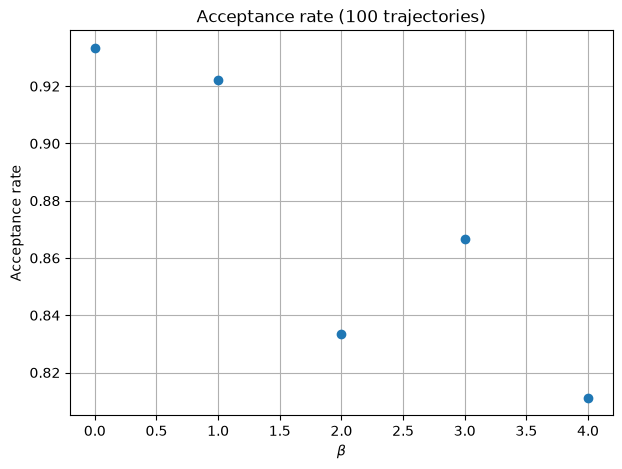

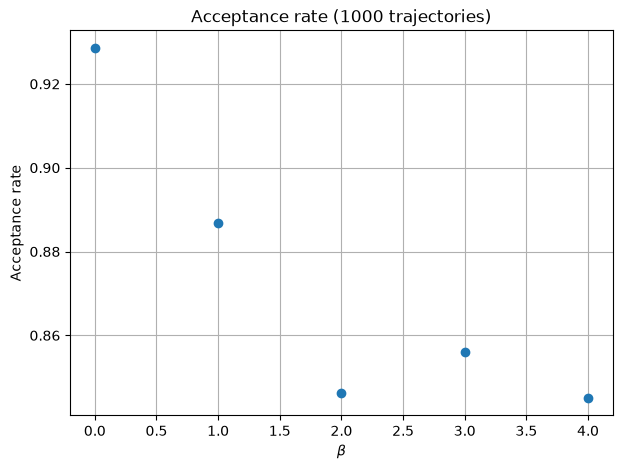

In [160]:
plot_acceptance(acc_100, trajectories=100)
plot_acceptance(acc_1000, trajectories=1000)

In [161]:
def parse_dH(logfile):

    data = []

    current_traj = None

    with open(logfile) as f:
        for line in f:

            m_traj = re.search(
                r"Plaquette:\s+\[\s*(\d+)\s*\]",
                line
            )

            if m_traj:
                current_traj = int(m_traj.group(1))


            m_dh = re.search(
                r"Total H after trajectory\s*=\s*([\d\.Ee+-]+)\s+dH\s*=\s*([\d\.Ee+-]+)",
                line
            )

            if m_dh and current_traj is not None:

                data.append({
                    "trajectory": current_traj,
                    "H_after": float(m_dh.group(1)),
                    "dH": float(m_dh.group(2))
                })

    return pd.DataFrame(data)

In [162]:
dh_measurements = []

for log in logs:

    dh = parse_dH(log)

    params = parse_log_name(log)

    for key,value in params.items():
        dh[key] = value

    dh["file"] = log.name

    dh_measurements.append(dh)


df_dh = pd.concat(dh_measurements)

df_dh = df_dh.drop_duplicates(
    subset=["file","trajectory"]
)


In [163]:
df_dh["exp_minus_dH"] = np.exp(-df_dh["dH"])

df_beta_scan_dh = df_dh[(df_dh.mdsteps == 10) & (df_dh.trajL == 1.0) & (df_dh.beta != 5.6)]
df_mdsteps_scan_dh = df_dh[(df_dh.beta == 2) & (df_dh.trajL == 1.0) & (df_dh.mdsteps != 40)]
df_trajL_scan_dh = df_dh[(df_dh.beta == 2) & (df_dh.mdsteps == 10)]

df_dh_traj100 = df_beta_scan_dh[(df_beta_scan_dh.trajectories==100)&(df_beta_scan_dh.trajectory >19)]
df_dh_traj1000 = df_beta_scan_dh[(df_beta_scan_dh.trajectories==1000)&(df_beta_scan_dh.trajectory >99)]

df_dh_mdsteps_traj100 = df_mdsteps_scan_dh[(df_mdsteps_scan_dh.trajectories==100)&(df_mdsteps_scan_dh.trajectory >19)]
df_dh_mdsteps_traj1000 = df_mdsteps_scan_dh[(df_mdsteps_scan_dh.trajectories==1000)&(df_mdsteps_scan_dh.trajectory >99)]

df_dh_trajL_traj100 = df_trajL_scan_dh[(df_trajL_scan_dh.trajectories==100)&(df_trajL_scan_dh.trajectory >19)]
df_dh_trajL_traj1000 = df_trajL_scan_dh[(df_trajL_scan_dh.trajectories==1000)&(df_trajL_scan_dh.trajectory >99)]


In [164]:
df_mdsteps5_dh = df_dh[(df_dh.mdsteps == 5)] #Achtung: für reversibility angepasst
df_mdsteps10_dh = df_dh[(df_dh.mdsteps == 10)]
df_mdsteps15_dh = df_dh[(df_dh.mdsteps == 15)]
df_mdsteps20_dh = df_dh[(df_dh.mdsteps == 20)]

In [165]:
def dH_stats(df):
    stats =(
    df    
    .groupby("beta")
    .dH
    .agg(
        mean="mean",
        std="std",
        N="count"
        )       
    )

    stats["sem"] = (
    stats["std"] /
    np.sqrt(stats["N"])
    )

    return stats

In [166]:
df_mdsteps_traj100.head()

,trajectory,plaquette,lattice,beta,mdsteps,trajL,trajectories,checkpoint,file
1010,1,0.291019,8x8x8x8,2.0,5,1.0,100,5,L8x8x8x8_beta2_md5_trajL1.0_traj100_ckpt5.log
1011,2,0.387264,8x8x8x8,2.0,5,1.0,100,5,L8x8x8x8_beta2_md5_trajL1.0_traj100_ckpt5.log
1012,3,0.437674,8x8x8x8,2.0,5,1.0,100,5,L8x8x8x8_beta2_md5_trajL1.0_traj100_ckpt5.log
1013,4,0.463869,8x8x8x8,2.0,5,1.0,100,5,L8x8x8x8_beta2_md5_trajL1.0_traj100_ckpt5.log
1014,5,0.477317,8x8x8x8,2.0,5,1.0,100,5,L8x8x8x8_beta2_md5_trajL1.0_traj100_ckpt5.log


In [167]:
dh_stats_traj100 = measurement_stats(df_dh_traj100, "dH" , "beta")
dh_stats_traj1000 = measurement_stats(df_dh_traj1000, "dH" , "beta")

dh_stats_mdsteps_traj100 = measurement_stats(df_dh_mdsteps_traj100, "dH", "mdsteps")
dh_stats_mdsteps_traj1000 = measurement_stats(df_dh_mdsteps_traj1000, "dH", "mdsteps")

dh_stats_trajL_traj100 = measurement_stats(df_dh_trajL_traj100, "dH", "trajL")
dh_stats_trajL_traj1000 = measurement_stats(df_dh_trajL_traj1000, "dH", "trajL")

In [168]:
df_dh_traj100

,trajectory,H_after,dH,lattice,beta,mdsteps,trajL,trajectories,checkpoint,file,exp_minus_dH
19,20,44805.944017,-0.092202,8x8x8x8,4.0,10,1.0,100,5,L8x8x8x8_beta4_md10_trajL1.0_traj100_ckpt5.log,1.096587
20,21,44575.959427,0.238086,8x8x8x8,4.0,10,1.0,100,5,L8x8x8x8_beta4_md10_trajL1.0_traj100_ckpt5.log,0.788135
21,22,44728.251590,-0.039821,8x8x8x8,4.0,10,1.0,100,5,L8x8x8x8_beta4_md10_trajL1.0_traj100_ckpt5.log,1.040625
22,23,44536.088501,-0.248131,8x8x8x8,4.0,10,1.0,100,5,L8x8x8x8_beta4_md10_trajL1.0_traj100_ckpt5.log,1.281628
23,24,44140.430006,0.303995,8x8x8x8,4.0,10,1.0,100,5,L8x8x8x8_beta4_md10_trajL1.0_traj100_ckpt5.log,0.737865
...,...,...,...,...,...,...,...,...,...,...,...
104,105,43499.054243,0.054732,8x8x8x8,10.0,10,1.0,100,5,L8x8x8x8_beta10_md10_trajL1.0_traj100_ckpt5.log,0.946739
105,106,43882.445291,0.283743,8x8x8x8,10.0,10,1.0,100,5,L8x8x8x8_beta10_md10_trajL1.0_traj100_ckpt5.log,0.752960
106,107,43901.856333,-0.736199,8x8x8x8,10.0,10,1.0,100,5,L8x8x8x8_beta10_md10_trajL1.0_traj100_ckpt5.log,2.087984
107,108,43596.361704,0.506214,8x8x8x8,10.0,10,1.0,100,5,L8x8x8x8_beta10_md10_trajL1.0_traj100_ckpt5.log,0.602773


In [169]:
dh_corr_traj100 = autocorr_error(df_dh_traj100, "dH", "beta", Wmax=90)

df_dh_traj100 = dh_stats_traj100.merge(dh_corr_traj100, on="beta")

dh_corr_traj1000 = autocorr_error(df_dh_traj1000, "dH", "beta", Wmax=900)

df_dh_traj1000 = dh_stats_traj1000.merge(dh_corr_traj1000, on="beta")

/var/folders/gn/0cpq6tpx3mb7dr15cprkp6s00000gn/T/ipykernel_73700/1981697336.py:13: RuntimeWarning: invalid value encountered in scalar divide
  gamma = np.sum((x1 - mean)*(x2 - mean))/(N-lag)


In [170]:
dh_corr_traj1000

,beta,tau_int,delta_tau,tau_exp,W_opt,gamma0,sem_autocorr
0,2.0,0.315624,0.030927,1.000000e-10,1,0.029799,0.004546
1,4.0,0.363836,0.035256,1.000000e-10,1,0.055341,0.006652
2,6.0,0.373984,0.036153,1.000000e-10,1,0.094767,0.008826
3,8.0,0.302745,0.029753,1.000000e-10,1,0.106727,0.008427
4,10.0,0.397221,0.038189,1.000000e-10,1,0.114705,0.010007


In [171]:
dh_stats_mdsteps5 = measurement_stats(df_mdsteps5_dh, "dH", "mdsteps")  # Achtung: für reversibility angepasst
dh_stats_mdsteps10 = measurement_stats(df_mdsteps10_dh, "dH", "mdsteps")
dh_stats_mdsteps15 = measurement_stats(df_mdsteps15_dh, "dH", "mdsteps")
dh_stats_mdsteps20 = measurement_stats(df_mdsteps20_dh, "dH", "mdsteps")

In [172]:
dh_mdsteps_revers = pd.concat([dh_stats_mdsteps5, dh_stats_mdsteps10, dh_stats_mdsteps15, dh_stats_mdsteps20], ignore_index=True)

In [173]:
#dh_mdsteps_revers.to_csv("/home/max/PhD/programs/su2/pure_gauge/assets/data/dH_measurements_mdsteps_revers.csv", index=False)

In [174]:
#Plotfunktion dH vs trajectories für alle beta
def plot_dH_history(df_plot, title=None):
    
    plt.figure(figsize=(8,5))

    for beta in sorted(df_plot.beta.unique()):
        subset = (
            df_plot[df_plot.beta == beta]
            .sort_values("trajectory")
        )

        plt.plot(
            subset.trajectory,
            subset.dH,
            ".",
            alpha=0.5,
            label=fr"$\beta={beta}$"
        )

    plt.xlabel("trajectory")
    plt.ylabel("dH")
    plt.legend()
    plt.grid()
    plt.axhline(0)

    if title:
        plt.title(title)

    plt.show()

In [175]:
plot_dH_history(df_dh_traj100, title="100 trajectories")
plot_dH_history(df_dh_traj1000, title="1000 trajectories")

KeyError: 'trajectory'

<Figure size 800x500 with 0 Axes>

In [ ]:
def plot_dH_histogram(df, beta=None, bins=40):

    plt.figure(figsize=(8,5))

    # Anzahl der Trajektorien aus DataFrame holen
    if "trajectories" in df.columns:
        traj_values = df.trajectories.unique()
        if len(traj_values) == 1:
            trajectories = traj_values[0]
        else:
            trajectories = None
    else:
        trajectories = None


    if beta is not None:

        df_plot = df[df.beta == beta]

        plt.hist(
            df_plot.dH,
            bins=bins,
            density=True,
            rwidth=0.9,
            alpha=0.7
        )

        title = (
            fr"$\Delta H$ distribution, "
            fr"$\beta={beta}$"
        )

    else:

        for b in sorted(df.beta.unique()):

            plt.hist(
                df[df.beta == b].dH,
                bins=bins,
                density=True,
                alpha=0.5,
                label=fr"$\beta={b}$"
            )

        plt.legend()

        title = r"$\Delta H$ distribution"


    if trajectories is not None:
        title += f" ({trajectories} trajectories)"


    plt.axvline(
        0,
        linestyle="--"
    )

    plt.xlabel(r"$\Delta H$")
    plt.ylabel("Probability density")

    plt.title(title)

    plt.grid()

    plt.show()

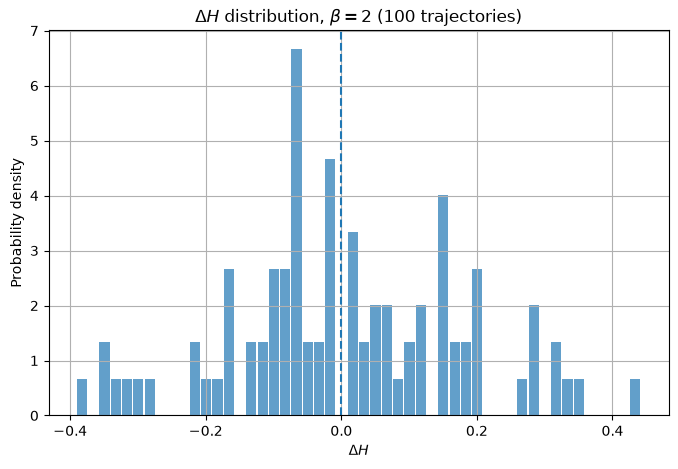

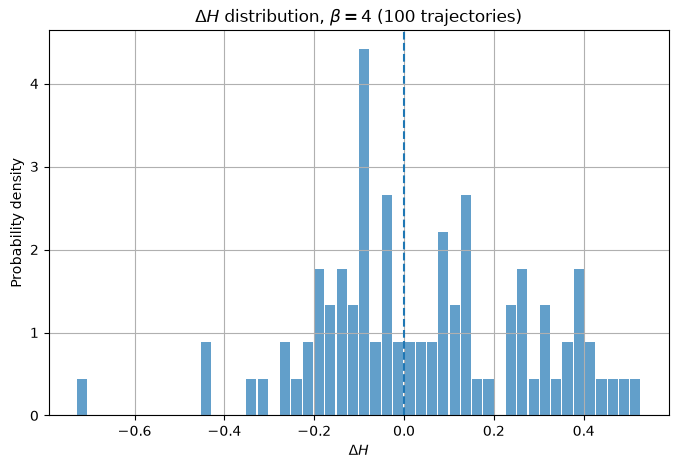

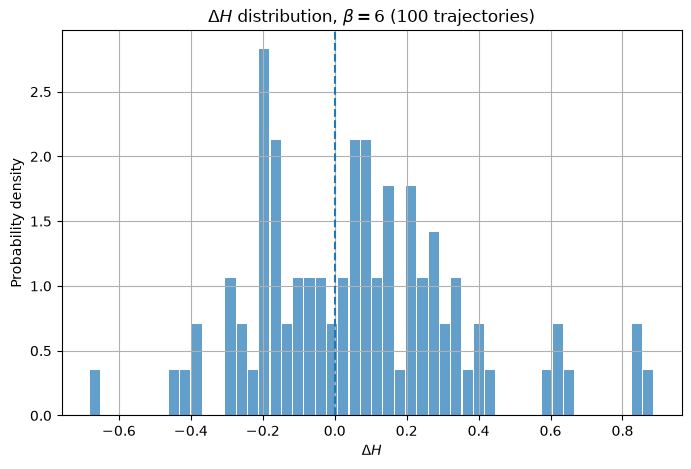

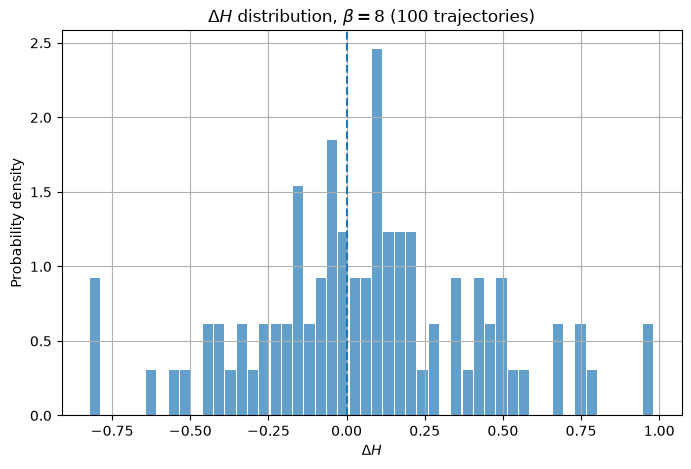

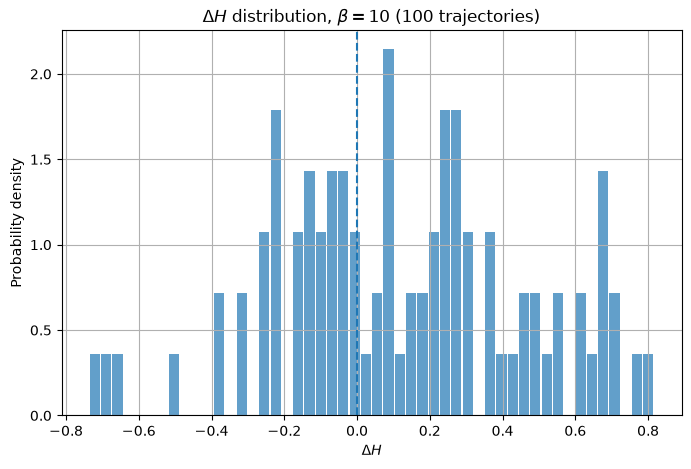

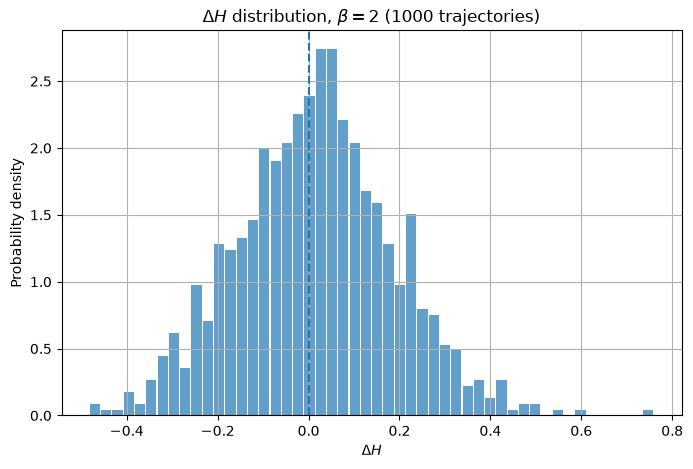

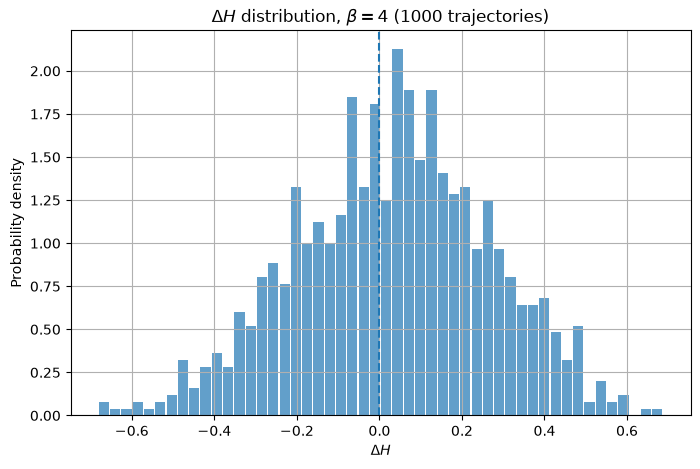

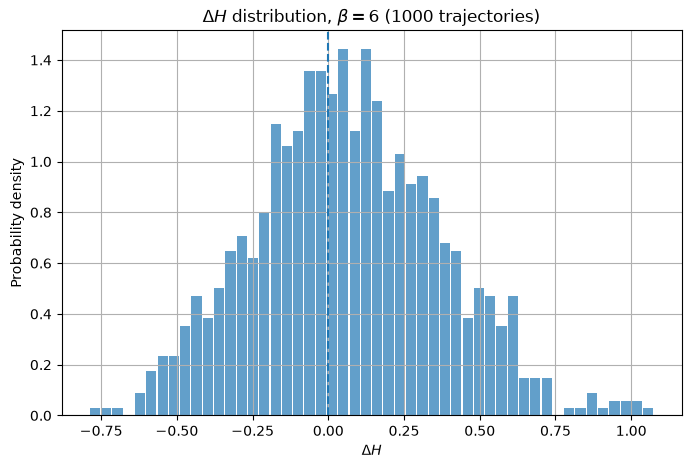

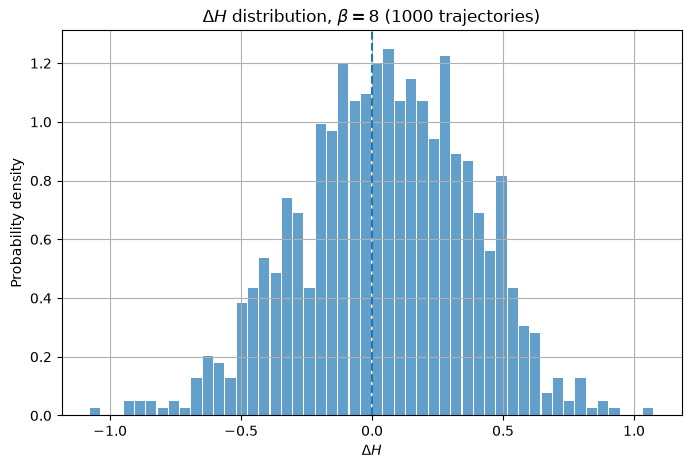

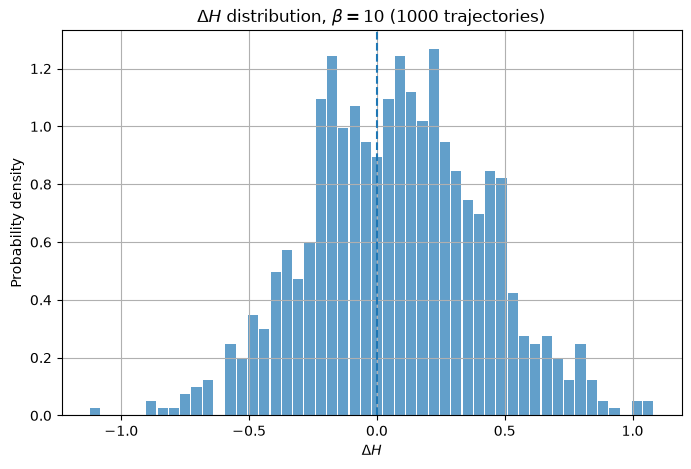

In [ ]:
plot_dH_histogram(df_dh_traj100, beta=2, bins=50)
plot_dH_histogram(df_dh_traj100,beta=4, bins=50)
plot_dH_histogram(df_dh_traj100,beta=6, bins=50)
plot_dH_histogram(df_dh_traj100,beta=8, bins=50)
plot_dH_histogram(df_dh_traj100,beta=10, bins=50)

plot_dH_histogram(df_dh_traj1000, beta=2, bins=50)
plot_dH_histogram(df_dh_traj1000,beta=4, bins=50)
plot_dH_histogram(df_dh_traj1000,beta=6, bins=50)
plot_dH_histogram(df_dh_traj1000,beta=8, bins=50)
plot_dH_histogram(df_dh_traj1000,beta=10, bins=50)

In [176]:
analysis_100 = df_dh_traj100.join(acc_100["acceptance"])
analysis_1000 = df_dh_traj1000.join(acc_1000["acceptance"])

#print(analysis_100.to_latex(index=False))
#print(analysis_1000.to_latex(index=False))

In [177]:
analysis_1000

,beta,N,mean,std,sem,tau_int,delta_tau,tau_exp,W_opt,gamma0,sem_autocorr,acceptance
0,2.0,910,0.016025,0.172717,0.005726,0.315624,0.030927,1.000000e-10,1,0.029799,0.004546,0.928571
1,4.0,910,0.032799,0.235376,0.007803,0.363836,0.035256,1.000000e-10,1,0.055341,0.006652,0.886813
2,6.0,910,0.063419,0.308012,0.010210,0.373984,0.036153,1.000000e-10,1,0.094767,0.008826,0.846154
3,8.0,910,0.049749,0.326870,0.010836,0.302745,0.029753,1.000000e-10,1,0.106727,0.008427,0.856044
4,10.0,910,0.077103,0.338868,0.011233,0.397221,0.038189,1.000000e-10,1,0.114705,0.010007,0.845055


In [ ]:
df_dh_traj100 

,beta,N,mean,std,sem,tau_int,W_opt,gamma0,sem_autocorr
0,2.0,90,0.004896,0.173860,0.018326,0.278924,1,0.029891,0.013612
1,4.0,90,0.041472,0.239281,0.025222,0.438907,1,0.056619,0.023500
2,6.0,90,0.066445,0.292599,0.030843,0.440225,1,0.084663,0.028779
3,8.0,90,0.062335,0.370234,0.039026,0.145527,1,0.135550,0.020937
4,10.0,90,0.122251,0.342594,0.036113,0.116057,1,0.116067,0.017301


In [ ]:
def plot_acceptance_vs_dH(df, trajectories=None, compare_autocorr=False):

    plt.figure(figsize=(8,5))

    plt.errorbar(
        df["mean"],
        df["acceptance"],
        xerr=df["sem"],
        fmt="o",
        capsize=4,
        label="naive"
    )

    if compare_autocorr:
        plt.errorbar(
            df["mean"],
            df["acceptance"],
            xerr=df["sem_autocorr"],
            fmt="none",
            capsize=7,
            label="autocorrelation corrected"
        )

    offsets = [
        (10, 10),
        (10, 10),
        (10, 10),
        (10, 10),
        (10, 10)
    ]

    for i, beta in enumerate(df["beta"]):

        plt.annotate(
            fr"$\beta={beta}$",
            (
                df.loc[i, "mean"],
                df.loc[i, "acceptance"]
            ),
            xytext=offsets[i % len(offsets)],
            textcoords="offset points"
        )

    plt.xlabel(r"$\langle \Delta H\rangle$")
    plt.ylabel("Acceptance rate")

    if trajectories:
        plt.title(
            r"Acceptance rate vs $\langle \Delta H\rangle$ "
            f"({trajectories} trajectories)"
        )
    else:
        plt.title(r"Acceptance rate vs $\langle \Delta H\rangle$")

    plt.margins(x=0.15, y=0.15)

    plt.grid()
    plt.legend()
    plt.show()

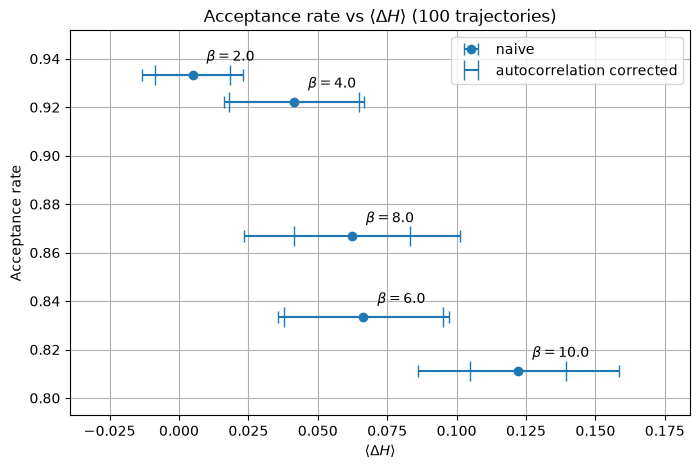

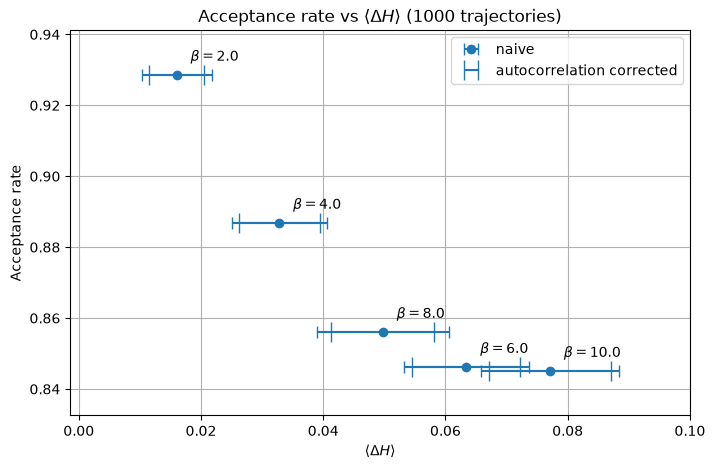

In [ ]:
plot_acceptance_vs_dH(analysis_100, trajectories=100, compare_autocorr=True)
plot_acceptance_vs_dH(analysis_1000, trajectories=1000, compare_autocorr=True)

In [ ]:
def exp_dH_stats(df):

    stats = (
        df
        .groupby("beta")
        .exp_minus_dH
        .agg(
            mean="mean",
            std="std",
            N="count"
        )
    )

    stats["sem"] = stats["std"] / np.sqrt(stats["N"])

    return stats

In [ ]:
exp_dH_100 = measurement_stats(df_dh_traj100, "exp_minus_dH", "beta")
exp_dH_1000 = measurement_stats(df_dh_traj1000, "exp_minus_dH", "beta")

exp_dH_mdsteps_100 = measurement_stats(df_dh_mdsteps_traj100, "exp_minus_dH", "mdsteps")
exp_dH_mdsteps_1000 = measurement_stats(df_dh_mdsteps_traj1000, "exp_minus_dH", "mdsteps")

exp_dH_trajL_100 = measurement_stats(df_dh_trajL_traj100, "exp_minus_dH", "trajL")
exp_dH_trajL_1000 = measurement_stats(df_dh_trajL_traj1000, "exp_minus_dH", "trajL")

In [ ]:
def plot_exp_dH(df_stats, trajectories=None):

    plt.figure(figsize=(8,5))

    plt.errorbar(
        df_stats["beta"],
        df_stats["mean"],
        yerr=df_stats["sem"],
        fmt="o",
        capsize=4
    )

    plt.axhline(
        1,
        linestyle="--",
        label=r"$\langle e^{-\Delta H}\rangle=1$"
    )

    plt.xlabel(r"$\beta$")
    plt.ylabel(r"$\langle e^{-\Delta H}\rangle$")

    if trajectories:
        plt.title(
            r"$\langle e^{-\Delta H}\rangle$ "
            f"({trajectories} trajectories)"
        )

    plt.grid()
    plt.legend()

    plt.show()

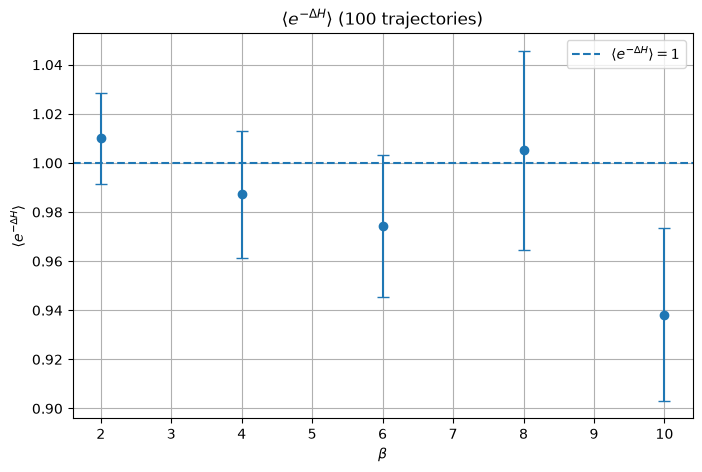

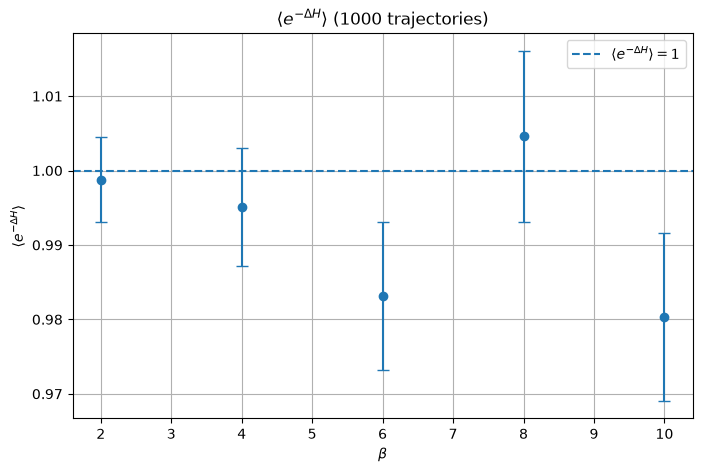

In [ ]:
plot_exp_dH(exp_dH_100, trajectories=100)
plot_exp_dH(exp_dH_1000, trajectories=1000)

In [ ]:
def plot_average_with_error(
    df,
    x,
    x_label,
    y_label,
    title=None,
    compare_autocorr=False,
):

    plt.figure(figsize=(7,5))

    # Naiver Fehler
    plt.errorbar(
        df[x],
        df["mean"],
        yerr=df["sem"],
        fmt="o",
        capsize=4,
        label="naive"
    )

    # Wolff-Fehler
    if compare_autocorr:
        plt.errorbar(
            df[x],
            df["mean"],
            yerr=df["sem_autocorr"],
            fmt="none",
            capsize=7,
            label="autocorrelation corrected"
        )
        plt.legend()

    plt.xlabel(x_label)
    plt.ylabel(y_label)

    if title:
        plt.title(title)

    plt.grid()
    plt.show()

In [ ]:
df_plaq_mdsteps_traj100["dtau"] = 1 / df_plaq_mdsteps_traj100["mdsteps"]
df_plaq_mdsteps_traj1000["dtau"] = 1 / df_plaq_mdsteps_traj1000["mdsteps"]

df_plaq_trajL_traj100["dtau"] = df_plaq_trajL_traj100["trajL"] /10
df_plaq_trajL_traj1000["dtau"] = df_plaq_trajL_traj1000["trajL"] /10

In [ ]:
df_plaq_trajL_traj1000

,trajL,N,mean,std,sem,tau_int,W_opt,gamma0,sem_autocorr,dtau
0,0.50,910,0.501701,0.003672,0.000122,5.802616,41,0.000013,0.000414,0.050
1,1.00,910,0.501585,0.003472,0.000115,3.146330,23,0.000012,0.000289,0.100
2,1.25,910,0.501189,0.003659,0.000121,2.797759,21,0.000013,0.000287,0.125
3,2.00,910,0.501458,0.003568,0.000118,7.556836,51,0.000013,0.000460,0.200


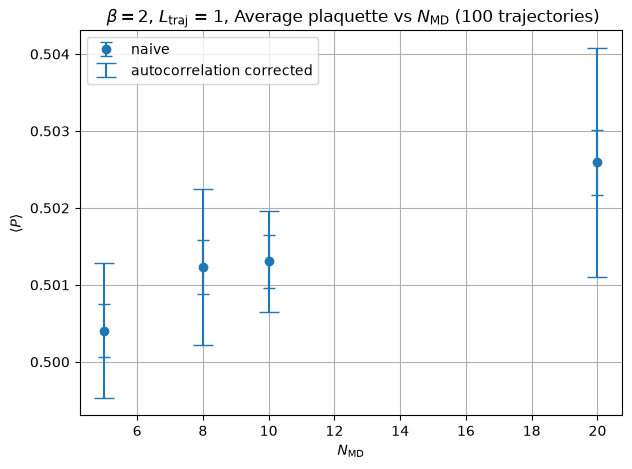

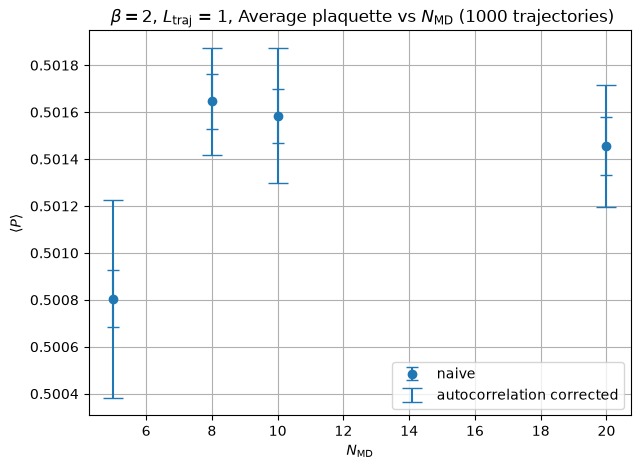

In [ ]:
plot_average_with_error(
    df_plaq_mdsteps_traj100,
    x="mdsteps",
    x_label=r"$N_{\mathrm{MD}}$",
    y_label=r"$\langle P\rangle$",
    title=r" $\beta = 2$, $L_{\mathrm{traj}}$ = 1, Average plaquette vs $N_{\mathrm{MD}}$ (100 trajectories)",
    compare_autocorr=True
)

plot_average_with_error(
    df_plaq_mdsteps_traj1000,
    x="mdsteps",
    x_label=r"$N_{\mathrm{MD}}$",
    y_label=r"$\langle P\rangle$",
    title=r" $\beta = 2$, $L_{\mathrm{traj}}$ = 1, Average plaquette vs $N_{\mathrm{MD}}$ (1000 trajectories)",
    compare_autocorr=True
)

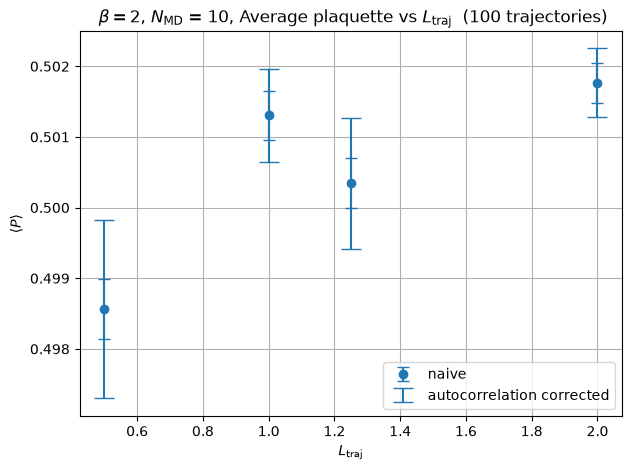

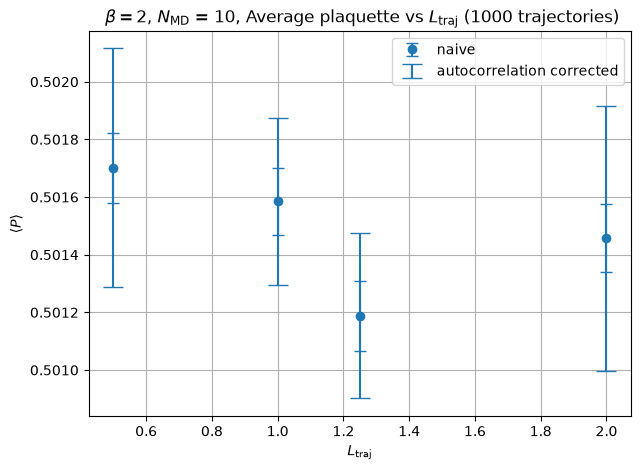

In [ ]:
plot_average_with_error(
    df_plaq_trajL_traj100,
    x="trajL",
    x_label=r"$L_{\mathrm{traj}}$",
    y_label=r"$\langle P\rangle$",
    title=r" $\beta = 2$, $N_{\mathrm{MD}}$ = 10, Average plaquette vs $L_{\mathrm{traj}}$  (100 trajectories)",
    compare_autocorr=True
)

plot_average_with_error(
    df_plaq_trajL_traj1000,
    x="trajL",
    x_label=r"$L_{\mathrm{traj}}$",
    y_label=r"$\langle P\rangle$",
    title=r" $\beta = 2$, $N_{\mathrm{MD}}$ = 10, Average plaquette vs $L_{\mathrm{traj}}$ (1000 trajectories)",
    compare_autocorr=True
)

In [ ]:
dh_stats_mdsteps_traj100["dtau"] = 1 / dh_stats_mdsteps_traj100["mdsteps"]
dh_stats_mdsteps_traj1000["dtau"] = 1 / dh_stats_mdsteps_traj1000["mdsteps"]

dh_stats_trajL_traj100["dtau"] = dh_stats_trajL_traj100["trajL"] /10
dh_stats_trajL_traj1000["dtau"] = dh_stats_trajL_traj1000["trajL"] /10

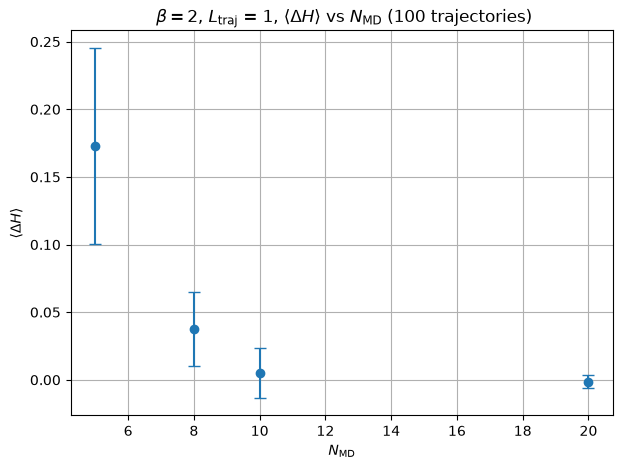

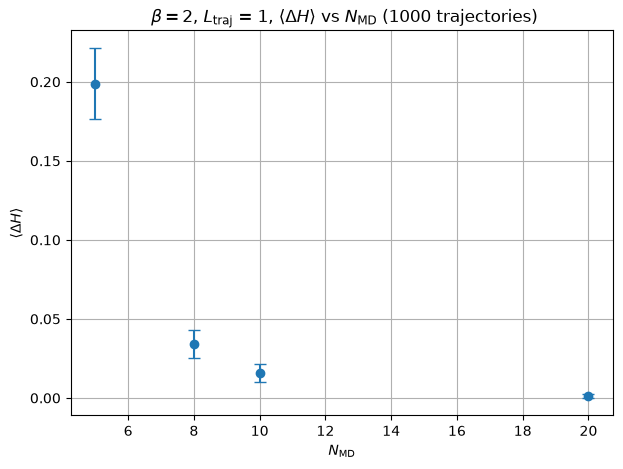

In [ ]:
plot_average_with_error(
    dh_stats_mdsteps_traj100,
    x="mdsteps",
    x_label=r"$N_{\mathrm{MD}}$",
    y_label=r"$\langle \Delta H \rangle$",
    title=r" $\beta = 2$, $L_{\mathrm{traj}}$ = 1, $\langle \Delta H \rangle$ vs $N_{\mathrm{MD}}$ (100 trajectories)"
)

plot_average_with_error(
    dh_stats_mdsteps_traj1000,
    x="mdsteps",
    x_label=r"$N_{\mathrm{MD}}$",
    y_label=r"$\langle \Delta H \rangle$",
    title=r" $\beta = 2$, $L_{\mathrm{traj}}$ = 1, $\langle \Delta H \rangle$ vs $N_{\mathrm{MD}}$ (1000 trajectories)"
)

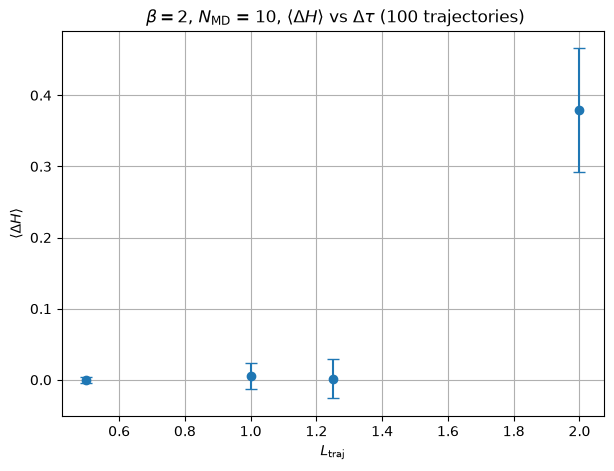

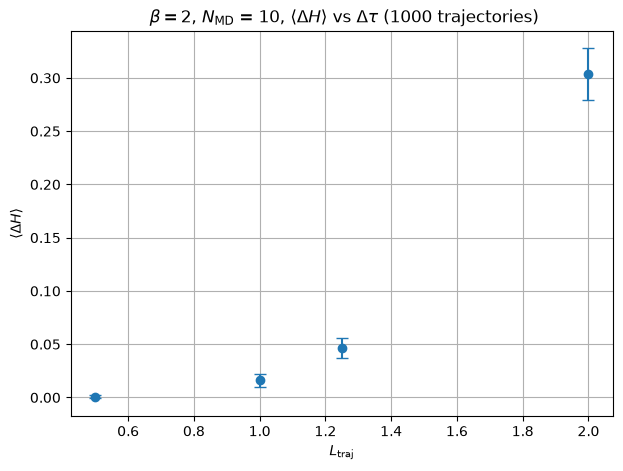

In [ ]:
plot_average_with_error(
    dh_stats_trajL_traj100,
    x="trajL",
    x_label=r"$L_{\mathrm{traj}}$",
    y_label=r"$\langle \Delta H \rangle$",
    title=r" $\beta = 2$, $N_{\mathrm{MD}}$ = 10, $\langle \Delta H \rangle$ vs $\Delta \tau$ (100 trajectories)"
)

plot_average_with_error(
    dh_stats_trajL_traj1000,
    x="trajL",
    x_label=r"$L_{\mathrm{traj}}$",
    y_label=r"$\langle \Delta H \rangle$",
    title=r" $\beta = 2$, $N_{\mathrm{MD}}$ = 10, $\langle \Delta H \rangle$ vs $\Delta \tau$ (1000 trajectories)"
)

In [ ]:
exp_dH_mdsteps_100["dtau"] = 1 / exp_dH_mdsteps_100["mdsteps"]
exp_dH_mdsteps_1000["dtau"] = 1 / exp_dH_mdsteps_1000["mdsteps"]

exp_dH_trajL_100["dtau"] = exp_dH_trajL_100["trajL"] /10
exp_dH_trajL_1000["dtau"] = exp_dH_trajL_1000["trajL"] /10

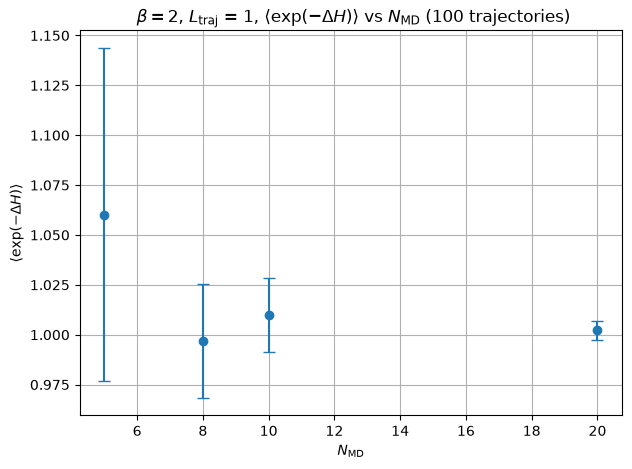

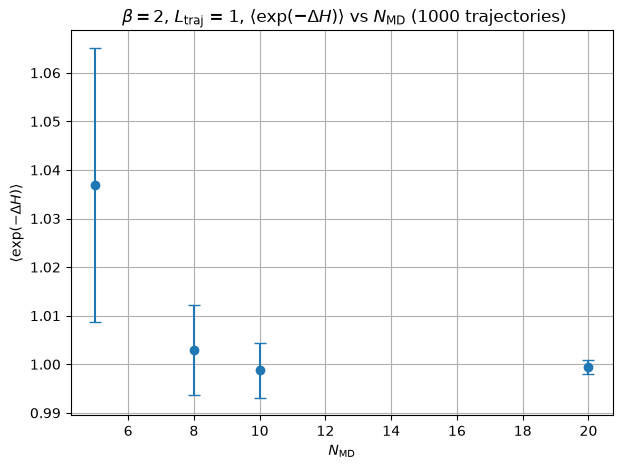

In [ ]:
plot_average_with_error(
    exp_dH_mdsteps_100,
    x="mdsteps",
    x_label=r"$N_{\mathrm{MD}}$",
    y_label=r"$\langle \exp(-\Delta H) \rangle$",
    title=r" $\beta = 2$, $L_{\mathrm{traj}}$ = 1, $\langle \exp(-\Delta H) \rangle$ vs $N_{\mathrm{MD}}$ (100 trajectories)"
)

plot_average_with_error(
    exp_dH_mdsteps_1000,
    x="mdsteps",
    x_label=r"$N_{\mathrm{MD}}$",
    y_label=r"$\langle \exp(-\Delta H) \rangle$",
    title=r" $\beta = 2$, $L_{\mathrm{traj}}$ = 1, $\langle \exp(-\Delta H) \rangle$ vs $N_{\mathrm{MD}}$ (1000 trajectories)"
)

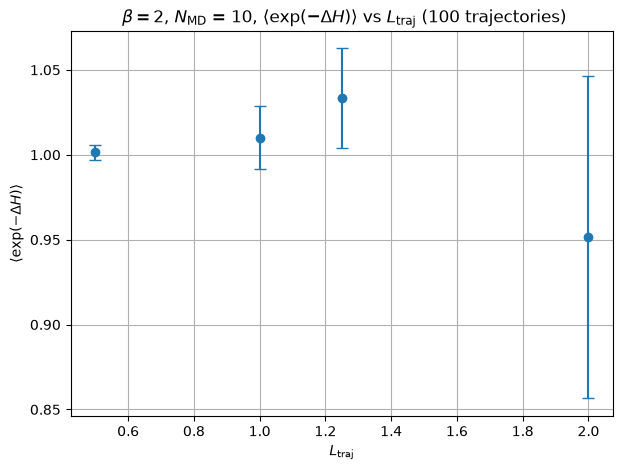

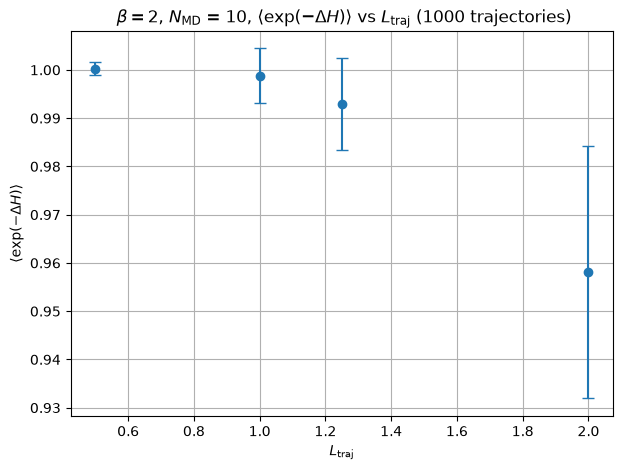

In [ ]:
plot_average_with_error(
    exp_dH_trajL_100,
    x="trajL",
    x_label=r"$L_{\mathrm{traj}}$",
    y_label=r"$\langle \exp(-\Delta H) \rangle$",
    title=r" $\beta = 2$, $N_{\mathrm{MD}}$ = 10, $\langle \exp(-\Delta H) \rangle$ vs $L_{\mathrm{traj}}$ (100 trajectories)"
)

plot_average_with_error(
    exp_dH_trajL_1000,
    x="trajL",
    x_label=r"$L_{\mathrm{traj}}$",
    y_label=r"$\langle \exp(-\Delta H) \rangle$",
    title=r" $\beta = 2$, $N_{\mathrm{MD}}$ = 10, $\langle \exp(-\Delta H) \rangle$ vs $L_{\mathrm{traj}}$ (1000 trajectories)"
)

In [ ]:
from matplotlib.lines import Line2D


def plot_integrator_comparison(
    df_mdsteps,
    df_trajL,
    observable,
    trajectories=None,
    reference=None,
    compare_autocorr=False
):

    plt.figure(figsize=(8,5))

    color_md = "tab:blue"
    color_traj = "tab:orange"


    # ==========================
    # N_MD scan
    # ==========================

    # naive error
    plt.errorbar(
        df_mdsteps["dtau"],
        df_mdsteps["mean"],
        yerr=df_mdsteps["sem"],
        fmt="o",
        color=color_md,
        ecolor=color_md,
        capsize=3,
        capthick=1,
        elinewidth=1,
        alpha=0.8,
        label=r"varying $N_{\mathrm{MD}}$"
    )

    # autocorrelation error
    if compare_autocorr:
        plt.errorbar(
            df_mdsteps["dtau"],
            df_mdsteps["mean"],
            yerr=df_mdsteps["sem_autocorr"],
            fmt="none",
            ecolor=color_md,
            capsize=8,
            capthick=2,
            elinewidth=3,
            alpha=0.35
        )


    # ==========================
    # L_traj scan
    # ==========================

    plt.errorbar(
        df_trajL["dtau"],
        df_trajL["mean"],
        yerr=df_trajL["sem"],
        fmt="s",
        color=color_traj,
        ecolor=color_traj,
        capsize=3,
        capthick=1,
        elinewidth=1,
        alpha=0.8,
        label=r"varying $L_{\mathrm{traj}}$"
    )

    if compare_autocorr:
        plt.errorbar(
            df_trajL["dtau"],
            df_trajL["mean"],
            yerr=df_trajL["sem_autocorr"],
            fmt="none",
            ecolor=color_traj,
            capsize=8,
            capthick=2,
            elinewidth=3,
            alpha=0.35
        )


    if reference is not None:
        plt.axhline(
            reference,
            color="black",
            linestyle=":",
            linewidth=1
        )


    # ==========================
    # legend
    # ==========================

    handles, labels = plt.gca().get_legend_handles_labels()

    if compare_autocorr:
        handles.extend([
            Line2D(
                [0],
                [0],
                color="black",
                linewidth=1,
                label="naive error"
            ),
            Line2D(
                [0],
                [0],
                color="black",
                linewidth=3,
                alpha=0.35,
                label="autocorrelation corrected"
            )
        ])

    plt.legend(handles=handles)


    plt.xlabel(r"$\Delta\tau=L_{\rm traj}/N_{\rm MD}$")
    plt.ylabel(observable)

    if trajectories is not None:
        plt.title(
            f"{observable} vs $\\Delta\\tau$ "
            f"({trajectories} trajectories)"
        )
    else:
        plt.title(
            f"{observable} vs $\\Delta\\tau$"
        )

    plt.grid()
    plt.show()

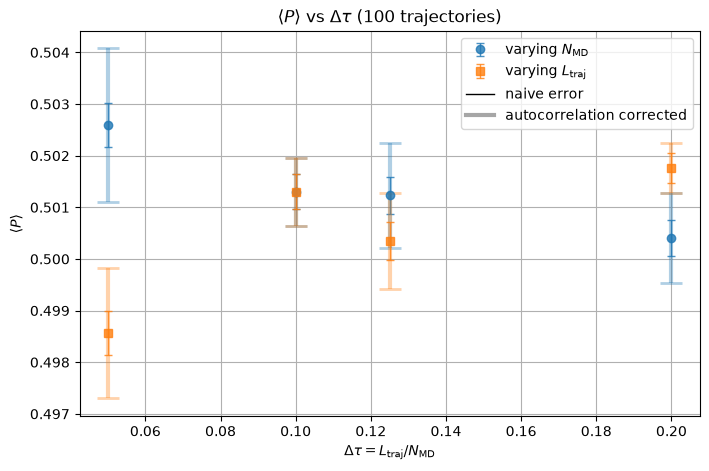

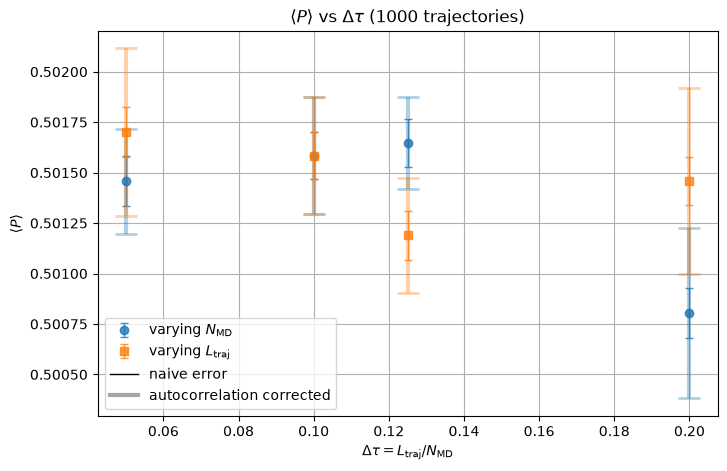

In [ ]:
plot_integrator_comparison(
    df_plaq_mdsteps_traj100,
    df_plaq_trajL_traj100,
    observable=r"$\langle P\rangle$",
    trajectories=100,
    compare_autocorr=True
)

plot_integrator_comparison(
    df_plaq_mdsteps_traj1000,
    df_plaq_trajL_traj1000,
    observable=r"$\langle P\rangle$",
    trajectories=1000,
    compare_autocorr=True
)

In [ ]:
plot_integrator_comparison(
    dh_stats_mdsteps_traj100,
    dh_stats_trajL_traj100,
    observable=r"$\langle \Delta H\rangle$",
    trajectories=100,
    compare_autocorr=True
)

plot_integrator_comparison(
    dh_stats_mdsteps_traj1000,
    dh_stats_trajL_traj1000,
    observable=r"$\langle \Delta H\rangle$",
    trajectories=1000,
    compare_autocorr=True
)

KeyError: 'dtau'

<Figure size 800x500 with 0 Axes>

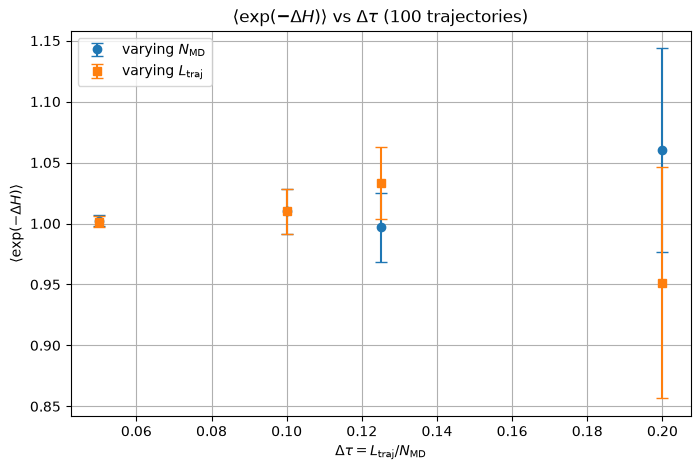

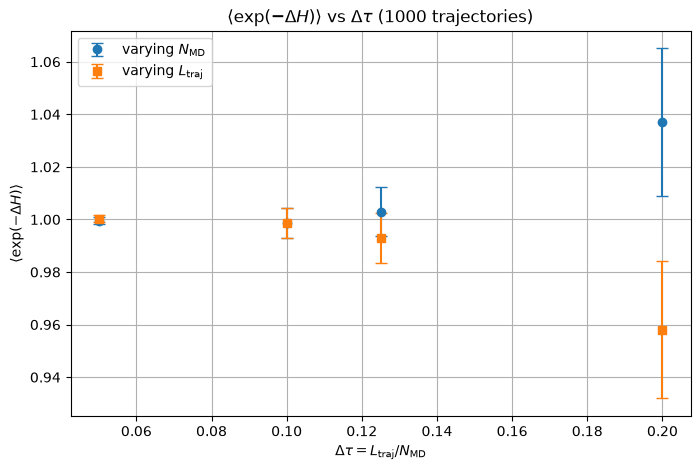

In [ ]:
plot_integrator_comparison(
    exp_dH_mdsteps_100,
    exp_dH_trajL_100,
    observable=r"$\langle \exp(-\Delta H)\rangle$",
    trajectories=100
)

plot_integrator_comparison(
    exp_dH_mdsteps_1000,
    exp_dH_trajL_1000,
    observable=r"$\langle \exp(-\Delta H) \rangle$",
    trajectories=1000
)

In [ ]:
#statsmodels.tsa.stattools.acf(x, adjusted=False, nlags=None, qstat=False, fft=True, alpha=None, bartlett_confint=True, missing='none')
# x=verwendete werte
# adjusted = normiere mit n oder n-k, k ist die differnz zwischen den zeitpunkten t_1 und t_2
# nlags = abstand bis zu dem werte verglichen werden
# qstat = irgendwas mit statisitk
# fft =acf durch fast fourier trafo (fft)
# alpha = gibt konfidenzintervall zurück, verwendet bartlett
# bartlett = art die standardabweichung zu berechnen
#missing = gibt an wie NaN behandelt werden 


In [ ]:
def parse_topology(log):

    data = []

    with open(log) as f:
        for line in f:

            m = re.search(
                r"Topological Charge:\s*\[\s*(\d+)\s*\]\s*([-0-9.eE+]+)",
                line
            )

            if m:
                data.append({
                    "trajectory": int(m.group(1)),
                    "Q": float(m.group(2))
                })

    return pd.DataFrame(data)

In [ ]:
q_measurements = []

for log in logs:

    q = parse_topology(log)

    params = parse_log_name(log)

    for key, value in params.items():
        q[key] = value

    q["file"] = log.name

    q_measurements.append(q)

df_q = pd.concat(q_measurements, ignore_index=True)

In [ ]:
df_q_traj100 = df_q[
    (df_q.trajectories == 100) &
    (df_q.trajectory > 20)
]

df_q_traj1000 = df_q[
    (df_q.trajectories == 1000) &
    (df_q.trajectory > 100)
]

In [ ]:
def plot_topology_history(df, beta=None, trajectories=None):

    plt.figure(figsize=(8,5))

    if beta is None:

        # Alle beta plotten
        for b in sorted(df.beta.unique()):

            subset = (
                df[df.beta == b]
                .sort_values("trajectory")
            )

            plt.plot(
                subset.trajectory,
                subset.Q,
                ".-",
                label=fr"$\beta={b}$"
            )

        title = "Topological charge"

        plt.legend()

    else:

        # Nur ein beta plotten
        subset = (
            df[df.beta == beta]
            .sort_values("trajectory")
        )

        plt.plot(
            subset.trajectory,
            subset.Q,
            ".-"
        )

        title = fr"Topological charge ($\beta={beta}$)"


    if trajectories is not None:
        title += f" ({trajectories} trajectories)"

    plt.axhline(
        0,
        color="black",
        linestyle="--",
        linewidth=1
    )

    plt.xlabel("Trajectory")
    plt.ylabel(r"$Q$")
    plt.title(title)

    plt.grid()

    plt.show()

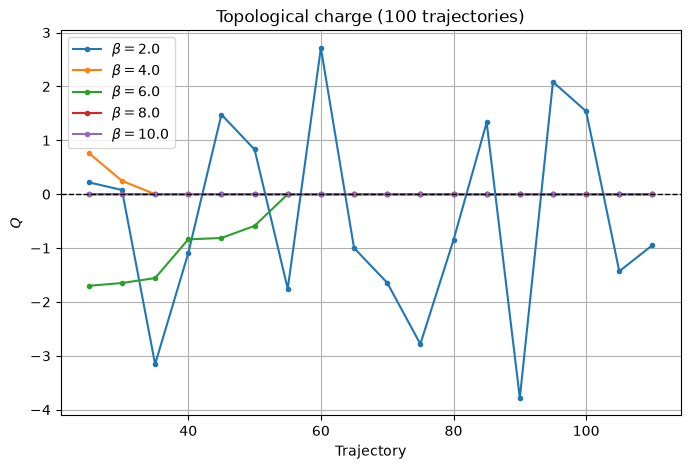

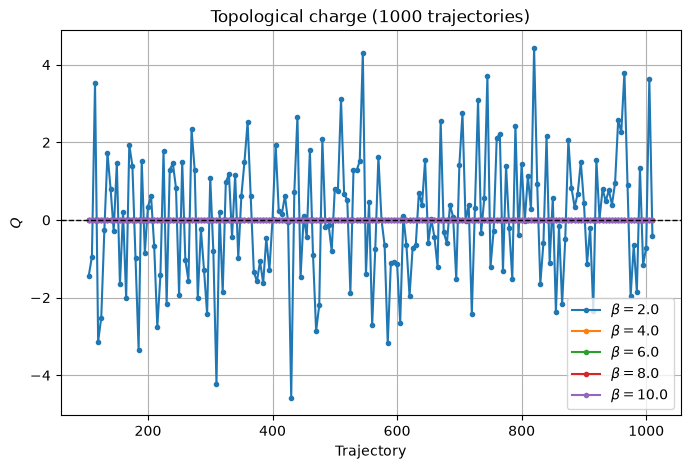

In [ ]:
plot_topology_history(
    df_q_traj100,
    trajectories=100
)
plot_topology_history(
    df_q_traj1000,
    trajectories=1000
)

In [ ]:
logfile = log_dir / "L8x8x8x8_beta6_md10_trajL1.0_traj100_ckpt5.log"

q = parse_topology(logfile)

q[:5]

[{'trajectory': 5, 'Q': -1.401114057529427},
 {'trajectory': 10, 'Q': -2.317731446012111},
 {'trajectory': 15, 'Q': -1.741037926784045},
 {'trajectory': 20, 'Q': -1.733078285691357},
 {'trajectory': 25, 'Q': -1.701356116330909}]

In [ ]:
top_measurements = []

for log in logs:

    params = parse_log_name(log)

    qs = parse_topology(log)

    for q in qs:
        q.update(params)
        q["file"] = log.name
        top_measurements.append(q)


qdf = pd.DataFrame(top_measurements)

qdf.head()

,trajectory,Q,lattice,beta,mdsteps,trajL,trajectories,checkpoint,file
0,5,0.800794,8x8x8x8,4.0,10,1.0,100,5,L8x8x8x8_beta4_md10_trajL1.0_traj100_ckpt5.log
1,10,-0.148791,8x8x8x8,4.0,10,1.0,100,5,L8x8x8x8_beta4_md10_trajL1.0_traj100_ckpt5.log
2,15,0.848236,8x8x8x8,4.0,10,1.0,100,5,L8x8x8x8_beta4_md10_trajL1.0_traj100_ckpt5.log
3,20,0.824696,8x8x8x8,4.0,10,1.0,100,5,L8x8x8x8_beta4_md10_trajL1.0_traj100_ckpt5.log
4,25,0.763690,8x8x8x8,4.0,10,1.0,100,5,L8x8x8x8_beta4_md10_trajL1.0_traj100_ckpt5.log


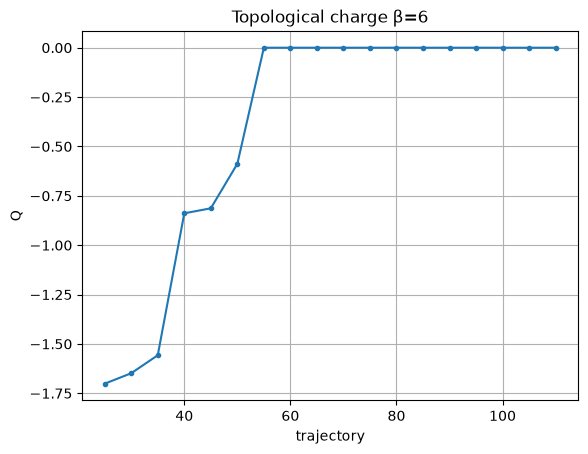

In [ ]:
subset = qdf[
    (qdf.beta == 6) &
    (qdf.trajectory > 20)
].sort_values("trajectory")

plt.plot(
    subset.trajectory,
    subset.Q,
    ".-"
)

plt.xlabel("trajectory")
plt.ylabel("Q")
plt.title("Topological charge β=6")
plt.grid()
plt.show()

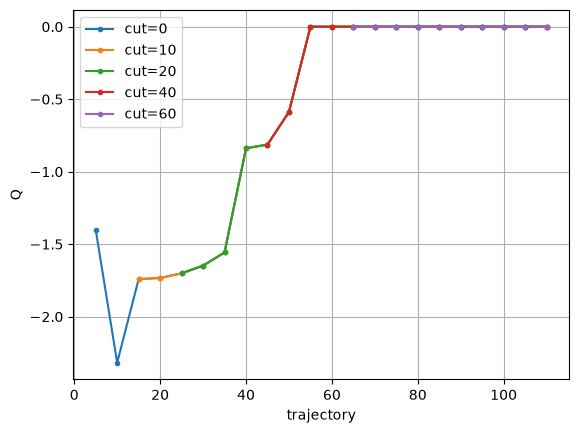

In [ ]:
for cut in [0,10,20,40,60]:

    subset = qdf[
        (qdf.beta == 6) &
        (qdf.trajectory > cut)
    ].sort_values("trajectory")

    plt.plot(
        subset.trajectory,
        subset.Q,
        ".-",
        label=f"cut={cut}"
    )

plt.xlabel("trajectory")
plt.ylabel("Q")
plt.legend()
plt.grid()
plt.show()

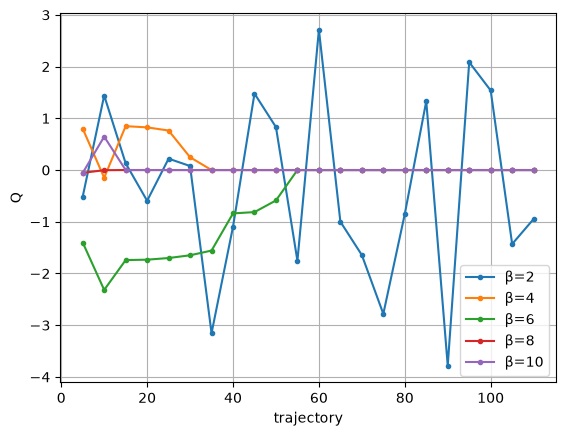

In [ ]:
for beta in [2,4,6,8,10]:

    subset = qdf[
        (qdf.beta == beta)
    ].sort_values("trajectory")

    plt.plot(
        subset.trajectory,
        subset.Q,
        ".-",
        label=f"β={beta}"
    )

plt.xlabel("trajectory")
plt.ylabel("Q")
plt.legend()
plt.grid()
plt.show()

In [3]:
from src.data import load_all_data
from src import analysis
from src import plot

df = load_all_data(log_dir)

print(df.shape)
print(df.columns.tolist())

df.head()

(12472, 14)
['trajectory', 'plaquette', 'lattice', 'beta', 'mdsteps', 'trajL', 'trajectories', 'checkpoint', 'file', 'H_after', 'dH', 'Q', 'accepted', 'exp_minus_dH']


,trajectory,plaquette,lattice,beta,mdsteps,trajL,trajectories,checkpoint,file,H_after,dH,Q,accepted,exp_minus_dH
0,1,0.282783,8x8x8x8,2.0,10,1.25,1000,5,L8x8x8x8_beta2_md10_trajL1.25_traj1000_ckpt5.log,59914.922013,-5.086844,NaN,NaN,161.878127
1,2,0.379957,8x8x8x8,2.0,10,1.25,1000,5,L8x8x8x8_beta2_md10_trajL1.25_traj1000_ckpt5.log,54886.967269,-3.163466,NaN,NaN,23.652435
2,3,0.432218,8x8x8x8,2.0,10,1.25,1000,5,L8x8x8x8_beta2_md10_trajL1.25_traj1000_ckpt5.log,52576.429905,-1.740324,NaN,NaN,5.699190
3,4,0.458476,8x8x8x8,2.0,10,1.25,1000,5,L8x8x8x8_beta2_md10_trajL1.25_traj1000_ckpt5.log,51225.064731,-0.863079,NaN,NaN,2.370449
4,5,0.476369,8x8x8x8,2.0,10,1.25,1000,5,L8x8x8x8_beta2_md10_trajL1.25_traj1000_ckpt5.log,50317.173737,-0.377843,-3.10498,NaN,1.459133


In [4]:
df_beta_long = analysis.select_scan(
    df,
    beta=[2, 4, 6, 8, 10],
    mdsteps=10,
    trajL=1.0,
    #lattice="8x8x8x8",
    trajectories=1000,
)

df_beta_long_therm = analysis.thermalized(
    df_beta_long,
    trajectory_cut=100,
)

plaquette_stats_long = analysis.measurement_stats(
    df_beta_long_therm,
    value="plaquette",
    groupby="beta",
)

plaquette_auto_long = analysis.autocorr_error(
    df_beta_long_therm,
    value="plaquette",
    groupby="beta",
    Wmax=900,
)

plaquette_stats_long = plaquette_stats_long.merge(
    plaquette_auto_long[
        [
            "beta",
            "tau_int",
            "delta_tau",
            "W_opt",
            "tau_exp",
            "gamma0",
            "sem_autocorr",
        ]
    ],
    on="beta",
)

In [5]:
plaquette_stats_long.head()

,beta,N,mean,std,sem_naive,tau_int,delta_tau,W_opt,tau_exp,gamma0,sem_autocorr
0,2.0,910,0.501585,0.003472,0.000115,3.174335,0.948821,23,3.147907,1.204381e-05,0.000290
1,4.0,910,0.799586,0.001505,0.000050,2.733979,0.764011,20,2.703222,2.263374e-06,0.000117
2,6.0,910,0.870059,0.000975,0.000032,2.532990,0.691744,19,2.499742,9.503811e-07,0.000073
3,8.0,910,0.903574,0.000711,0.000024,3.063675,0.918234,23,3.036278,5.043475e-07,0.000058
4,10.0,910,0.923319,0.000558,0.000018,3.153538,0.943087,23,3.126934,3.110204e-07,0.000046


In [5]:
df_beta_long_therm_auto_jackknife = analysis.jackknife_autocorr_scan(
    df_beta_long_therm,
    value="plaquette",
    groupby="beta",
    max_lag=30,
    n_blocks=10
)

<Axes: title={'center': 'Autocorrelation function of plaquette for different β values'}, xlabel='$t$', ylabel='$\\rho(t)$'>

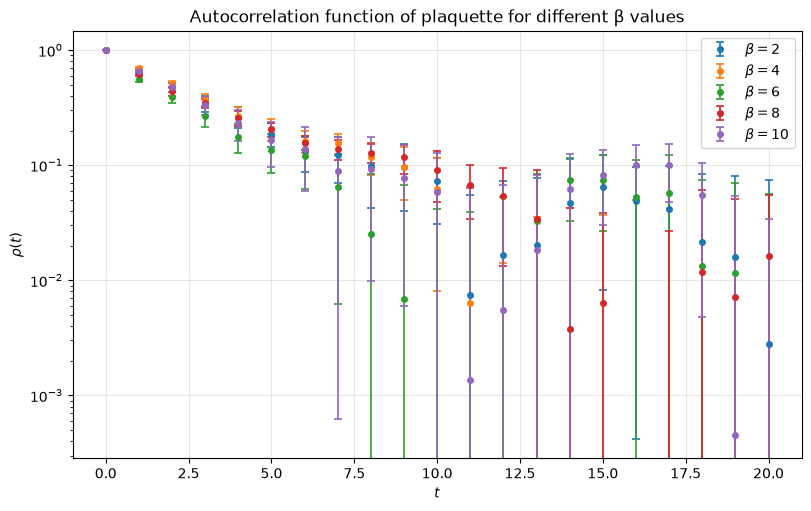

In [6]:
plot.plot_autocorr_scan(
    df_beta_long_therm_auto_jackknife,
    betas=[2, 4, 6, 8, 10],
    max_lag=20,
    title="Autocorrelation function of plaquette for different β values"
)

In [7]:
tau_scan = analysis.integrated_autocorr_time_scan(
    df_beta_long,
    value="plaquette",
    groupby="beta",
    Wmax=30,
)

<Axes: title={'center': 'Integrated autocorrelation time of the plaquette'}, xlabel='$W$', ylabel='$\\tau_{\\mathrm{int}}(W)$'>

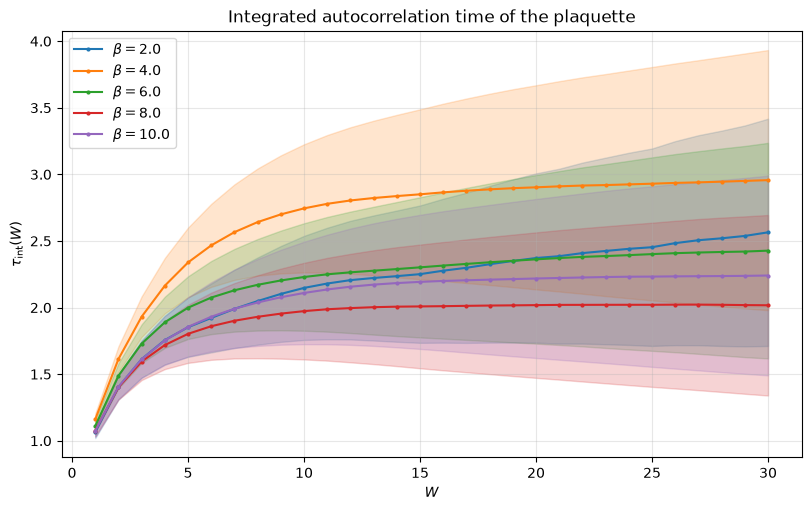

In [8]:
fig, ax = plt.subplots(
    figsize=(8, 5),
    layout="constrained",
)

plot.plot_int_autocorr_scan(
    tau_scan,
    ax=ax,
    title=(
        r"Integrated autocorrelation time "
        r"of the plaquette"
    ),
)



In [6]:
dH_stats_long = analysis.measurement_stats(
    df_beta_long_therm,
    value="dH",
    groupby="beta",
)

exp_dH_stats_long = analysis.measurement_stats(
    df_beta_long_therm,
    value="exp_minus_dH",
    groupby="beta",
)

acc_stats_long = analysis.acceptance_stats(
    df_beta_long_therm,
    groupby="beta",
)





In [10]:
print(dH_stats_long.head(10))

   beta    N      mean       std  sem_naive
0   2.0  909  0.015987  0.172809   0.005732
1   4.0  909  0.032646  0.235461   0.007810
2   6.0  909  0.063386  0.308180   0.010222
3   8.0  909  0.050241  0.326713   0.010836
4  10.0  909  0.077261  0.339021   0.011245


In [7]:
dH_auto_long = analysis.autocorr_error(
    df_beta_long_therm,
    value="dH",
    groupby="beta",
    Wmax=900,
)

exp_dH_auto_long = analysis.autocorr_error(
    df_beta_long_therm,
    value="exp_minus_dH",
    groupby="beta",
    Wmax=900,
)

acc_stats_long = analysis.acceptance_stats(
    df_beta_long_therm,
    groupby="beta",
)

In [8]:
dh_acc_stats_long = dH_auto_long.merge(
    acc_stats_long[
        [
            "beta",
            "N",
            "accepted",
            "acceptance",
            
        ]
    ],
    on="beta",)

In [9]:
#print(dH_auto_long.head())
print(exp_dH_auto_long.head())
#print(acc_stats_long.head())
#print(dh_acc_stats_long.head(10))

       mean   tau_int  delta_tau  W_opt       tau_exp    gamma0  sem_autocorr  \
0  0.998818  0.307350   0.022266      1  1.000000e-10  0.029574      0.004472   
1  0.995292  0.374287   0.026343      1  1.000000e-10  0.057625      0.006889   
2  0.983242  0.362966   0.025674      1  1.000000e-10  0.090084      0.008482   
3  1.004056  0.324904   0.023364      1  1.000000e-10  0.119549      0.009245   
4  0.980233  0.396790   0.027646      1  1.000000e-10  0.116094      0.010067   

   beta  
0   2.0  
1   4.0  
2   6.0  
3   8.0  
4  10.0  


<Axes: xlabel='$\\beta$', ylabel='Acceptance rate'>

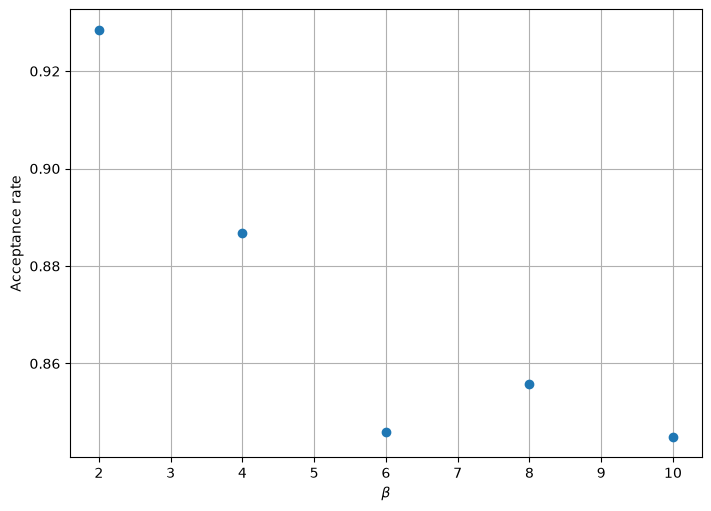

In [10]:
plot.plot_acceptance(acc_stats_long)

<Axes: title={'center': 'Acceptance rate vs $\\langle \\Delta H\\rangle$'}, xlabel='$\\langle \\Delta H\\rangle$', ylabel='Acceptance rate'>

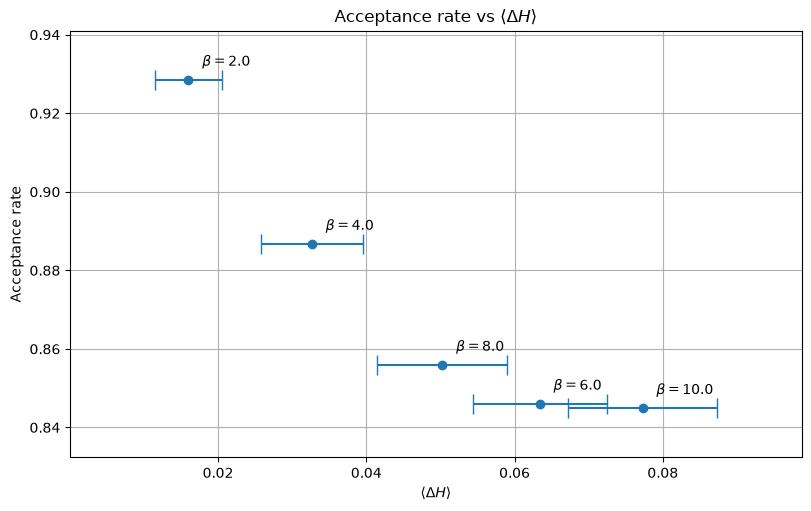

In [11]:
plot.plot_acceptance_vs_dH(dh_acc_stats_long, compare_naive=False)
    

In [12]:
exp_dH_auto_long 

,mean,tau_int,delta_tau,W_opt,tau_exp,gamma0,sem_autocorr,beta
0,0.998818,0.307350,0.022266,1,1.000000e-10,0.029574,0.004472,2.0
1,0.995292,0.374287,0.026343,1,1.000000e-10,0.057625,0.006889,4.0
2,0.983242,0.362966,0.025674,1,1.000000e-10,0.090084,0.008482,6.0
3,1.004056,0.324904,0.023364,1,1.000000e-10,0.119549,0.009245,8.0
4,0.980233,0.396790,0.027646,1,1.000000e-10,0.116094,0.010067,10.0


<Axes: xlabel='$\\beta$', ylabel='$\\langle e^{-\\Delta H}\\rangle$'>

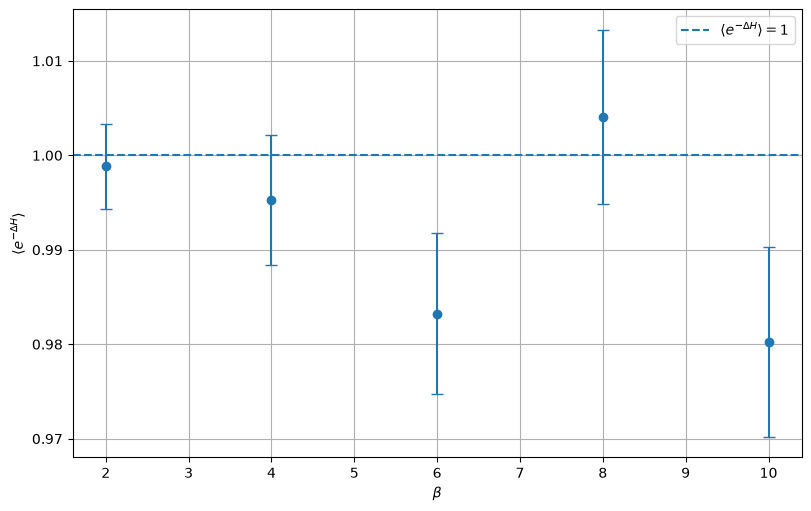

In [15]:
plot.plot_exp_dH(exp_dH_auto_long)